<a href="https://colab.research.google.com/github/Isadora220825/SSD/blob/main/Trabalho_1_SSD_(MVP_Student_Stress_Monitoring).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
# ============================================================
# CELULA 1 — Instalacao e importacao de bibliotecas
# ============================================================

# instala o xgboost que nao vem por padrao no Colab
!pip install xgboost --quiet

import pandas as pd               # manipulacao de tabelas
import numpy as np                 # operacoes matematicas
import matplotlib.pyplot as plt    # graficos
import seaborn as sns              # graficos estatisticos
import warnings                    # controle de avisos

# configuracoes visuais globais
plt.rcParams['figure.figsize'] = (12, 5)   # tamanho padrao dos graficos
plt.rcParams['axes.grid'] = True            # grade em todos os graficos
sns.set_theme(style='whitegrid')            # tema visual limpo
warnings.filterwarnings('ignore')           # suprime avisos de versao

# seed global para reprodutibilidade
np.random.seed(42)

print("Bibliotecas importadas com sucesso!")



Bibliotecas importadas com sucesso!


In [24]:
# ============================================================
# CELULA 2 — Carga do dataset
# ============================================================

# faz upload do arquivo CSV no Colab
from google.colab import files
uploaded = files.upload()   # selecione o arquivo StressLevelDataset.csv

# carrega o CSV em um DataFrame
df = pd.read_csv('StressLevelDataset.csv')

print(f"Dataset carregado!")
print(f"Linhas: {df.shape[0]} | Colunas: {df.shape[1]}")


Saving StressLevelDataset.csv to StressLevelDataset (1).csv
Dataset carregado!
Linhas: 1100 | Colunas: 21


In [25]:
# ============================================================
# CELULA 3 — Inspecao inicial do dataset
# ============================================================

print("=== Primeiras 5 linhas ===")
display(df.head())

print("\n=== Tipos de dados ===")
print(df.dtypes)

print("\n=== Valores faltantes ===")
print(df.isnull().sum())
# esperamos zero em todas — dataset limpo

print("\n=== Estatisticas descritivas ===")
display(df.describe().round(2))

=== Primeiras 5 linhas ===


,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,...,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,...,3,4,3,1,2,1,5,0,5,1



=== Tipos de dados ===
anxiety_level                   int64
self_esteem                     int64
mental_health_history           int64
depression                      int64
headache                        int64
blood_pressure                  int64
sleep_quality                   int64
breathing_problem               int64
noise_level                     int64
living_conditions               int64
safety                          int64
basic_needs                     int64
academic_performance            int64
study_load                      int64
teacher_student_relationship    int64
future_career_concerns          int64
social_support                  int64
peer_pressure                   int64
extracurricular_activities      int64
bullying                        int64
stress_level                    int64
dtype: object

=== Valores faltantes ===
anxiety_level                   0
self_esteem                     0
mental_health_history           0
depression                      0
h

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
count,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00,...,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00
mean,11.06,17.78,0.49,12.56,2.51,2.18,2.66,2.75,2.65,2.52,...,2.77,2.77,2.62,2.65,2.65,1.88,2.73,2.77,2.62,1.00
std,6.12,8.94,0.50,7.73,1.41,0.83,1.55,1.40,1.33,1.12,...,1.43,1.41,1.32,1.38,1.53,1.05,1.43,1.42,1.53,0.82
min,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,6.00,11.00,0.00,6.00,1.00,1.00,1.00,2.00,2.00,2.00,...,2.00,2.00,2.00,2.00,1.00,1.00,2.00,2.00,1.00,0.00
50%,11.00,19.00,0.00,12.00,3.00,2.00,2.50,3.00,3.00,2.00,...,3.00,2.00,2.00,2.00,2.00,2.00,2.00,2.50,3.00,1.00
75%,16.00,26.00,1.00,19.00,3.00,3.00,4.00,4.00,3.00,3.00,...,4.00,4.00,3.00,4.00,4.00,3.00,4.00,4.00,4.00,2.00
max,21.00,30.00,1.00,27.00,5.00,3.00,5.00,5.00,5.00,5.00,...,5.00,5.00,5.00,5.00,5.00,3.00,5.00,5.00,5.00,2.00


In [26]:
# ============================================================
# CELULA 4 — Organizacao das features por categoria
# ============================================================

# as 20 features do dataset se organizam em 5 categorias cientificas
# essa organizacao ajuda a entender os fatores de estresse

categorias = {
    'Psicologica': ['anxiety_level', 'self_esteem',
                    'mental_health_history', 'depression'],
    'Fisiologica': ['headache', 'blood_pressure',
                    'sleep_quality', 'breathing_problem'],
    'Ambiental':   ['noise_level', 'living_conditions',
                    'safety', 'basic_needs'],
    'Academica':   ['academic_performance', 'study_load',
                    'teacher_student_relationship',
                    'future_career_concerns'],
    'Social':      ['social_support', 'peer_pressure',
                    'extracurricular_activities', 'bullying']
}

# lista de todas as features (sem o target)
features = [f for cat in categorias.values() for f in cat]

# mapeamento dos niveis de estresse para nomes legiveis
mapa_estresse = {0: 'Sem Estresse', 1: 'Eustresse', 2: 'Distresse'}
df['stress_nome'] = df['stress_level'].map(mapa_estresse)

print("=== Categorias de Features ===")
for cat, feats in categorias.items():
    print(f"\n{cat}: {feats}")

print(f"\nTotal de features: {len(features)}")
print(f"Target: stress_level (0=Sem Estresse, 1=Eustresse, 2=Distresse)")



=== Categorias de Features ===

Psicologica: ['anxiety_level', 'self_esteem', 'mental_health_history', 'depression']

Fisiologica: ['headache', 'blood_pressure', 'sleep_quality', 'breathing_problem']

Ambiental: ['noise_level', 'living_conditions', 'safety', 'basic_needs']

Academica: ['academic_performance', 'study_load', 'teacher_student_relationship', 'future_career_concerns']

Social: ['social_support', 'peer_pressure', 'extracurricular_activities', 'bullying']

Total de features: 20
Target: stress_level (0=Sem Estresse, 1=Eustresse, 2=Distresse)


=== Distribuicao dos Niveis de Estresse ===

stress_level
0    373
1    358
2    369
Name: count, dtype: int64

Proporções:
stress_level
0    33.9
1    32.5
2    33.5
Name: proportion, dtype: float64


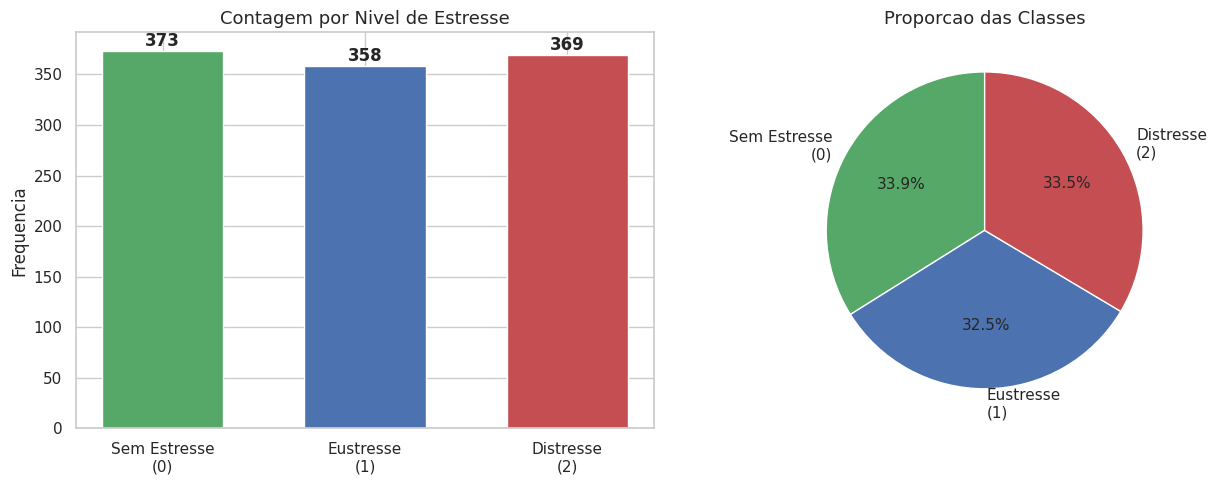


Classes razoavelmente balanceadas — nao sera necessario SMOTE.


In [27]:
# ============================================================
# CELULA 5 — Distribuicao da variavel alvo
# ============================================================

print("=== Distribuicao dos Niveis de Estresse ===\n")

contagem = df['stress_level'].value_counts().sort_index()
print(contagem)
print(f"\nProporções:")
print(df['stress_level'].value_counts(normalize=True).sort_index().mul(100).round(1))

# grafico de barras + pizza lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# barras
cores_stress = ['#55A868', '#4C72B0', '#C44E52']
nomes = ['Sem Estresse\n(0)', 'Eustresse\n(1)', 'Distresse\n(2)']
barras = ax1.bar(nomes, contagem.values, color=cores_stress, edgecolor='white', width=0.6)
for b in barras:
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+5,
             str(int(b.get_height())), ha='center', fontweight='bold')
ax1.set_title('Contagem por Nivel de Estresse', fontsize=13)
ax1.set_ylabel('Frequencia')

# pizza
ax2.pie(contagem.values, labels=nomes, autopct='%1.1f%%',
        colors=cores_stress, startangle=90, textprops={'fontsize':11})
ax2.set_title('Proporcao das Classes', fontsize=13)

plt.tight_layout()
plt.show()

print("\nClasses razoavelmente balanceadas — nao sera necessario SMOTE.")


In [28]:
# ============================================================
# CELULA 6 — Estatisticas descritivas por nivel de estresse
# ============================================================

print("=== Media de cada feature por nivel de estresse ===\n")

# agrupa por nivel de estresse e calcula a media
medias = df.groupby('stress_level')[features].mean().round(2)
medias.index = ['Sem Estresse', 'Eustresse', 'Distresse']
display(medias)



=== Media de cada feature por nivel de estresse ===



,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,safety,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying
Sem Estresse,5.43,25.25,0.10,6.01,1.31,2.20,4.13,1.70,1.65,3.31,4.10,4.14,4.14,1.65,3.93,1.34,2.54,1.68,1.72,1.25
Eustresse,11.43,19.26,0.49,11.87,2.46,1.32,2.53,2.93,2.51,2.50,2.42,2.48,2.49,2.53,2.36,2.52,2.18,2.46,2.48,2.56
Distresse,16.40,8.78,0.89,19.83,3.76,3.00,1.30,3.65,3.79,1.73,1.67,1.67,1.66,3.69,1.64,4.10,0.93,4.07,4.11,4.05


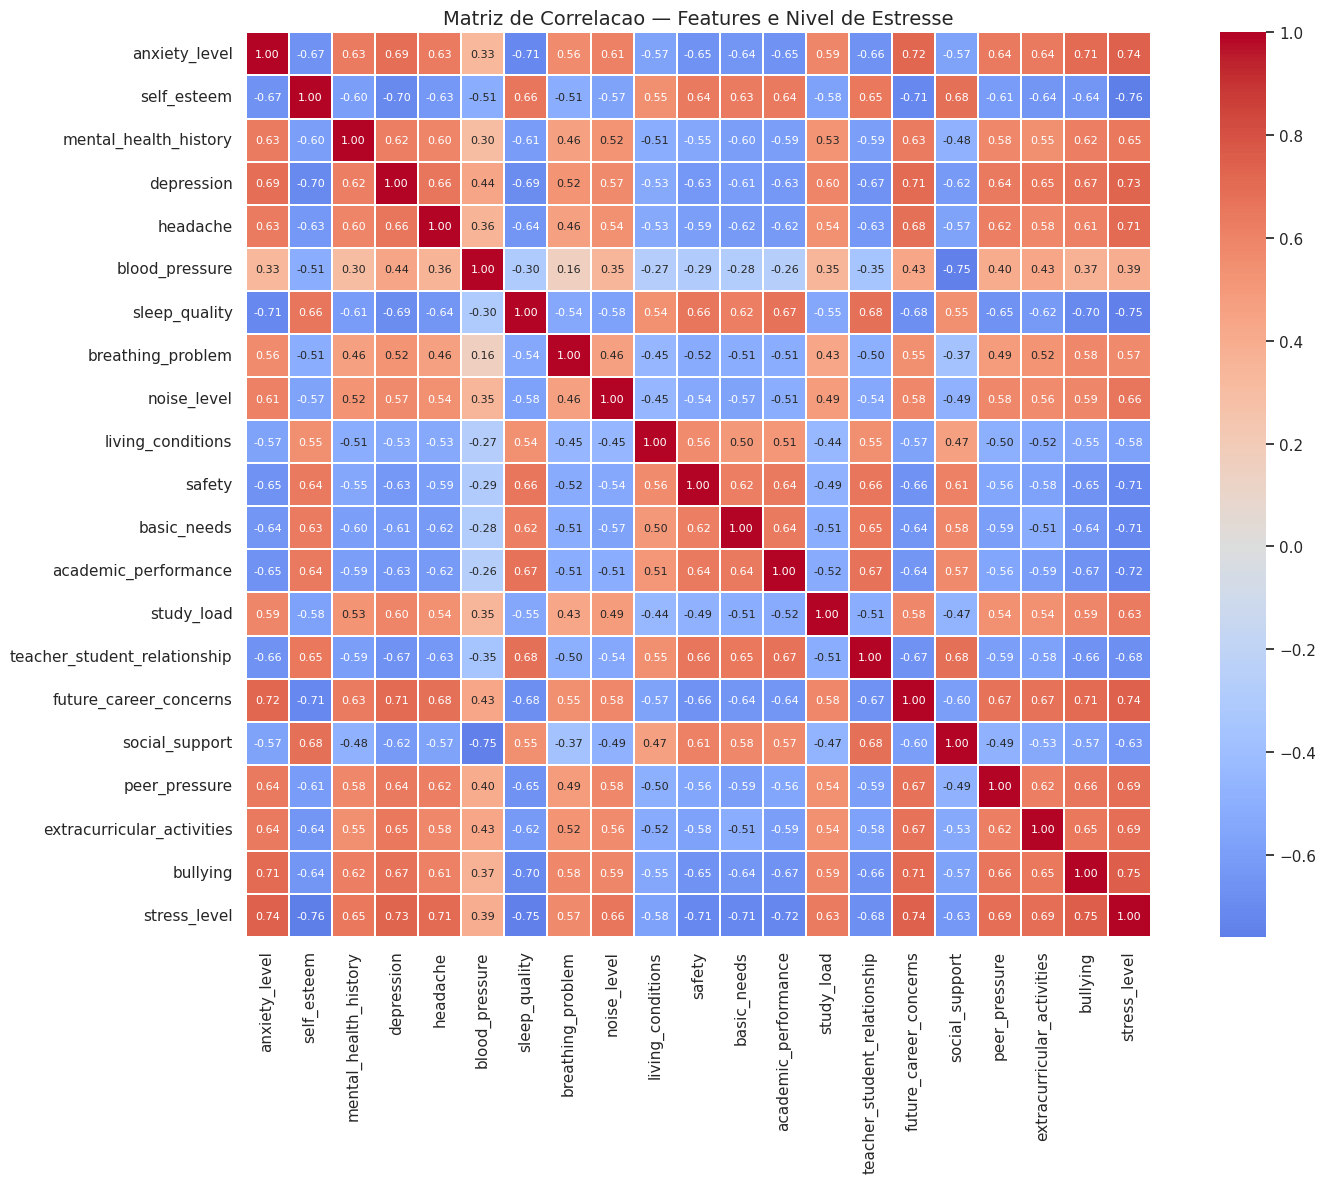


=== Top 10 correlacoes com stress_level ===
  1. self_esteem                         -0.76
  2. sleep_quality                       -0.75
  3. bullying                            +0.75
  4. anxiety_level                       +0.74
  5. future_career_concerns              +0.74
  6. depression                          +0.73
  7. academic_performance                -0.72
  8. safety                              -0.71
  9. basic_needs                         -0.71
  10. headache                            +0.71


In [29]:
# ============================================================
# CELULA 7 — Matriz de correlacao
# ============================================================

# calcula a correlacao de Pearson entre todas as variaveis
corr = df[features + ['stress_level']].corr().round(2)

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.3, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Matriz de Correlacao — Features e Nivel de Estresse', fontsize=14)
plt.tight_layout()
plt.show()

# correlacoes mais fortes com o target
print("\n=== Top 10 correlacoes com stress_level ===")
corr_target = corr['stress_level'].drop('stress_level').abs().sort_values(ascending=False)
for i, (feat, val) in enumerate(corr_target.head(10).items(), 1):
    sinal = '+' if corr.loc[feat, 'stress_level'] > 0 else '-'
    print(f"  {i}. {feat:<35} {sinal}{val:.2f}")


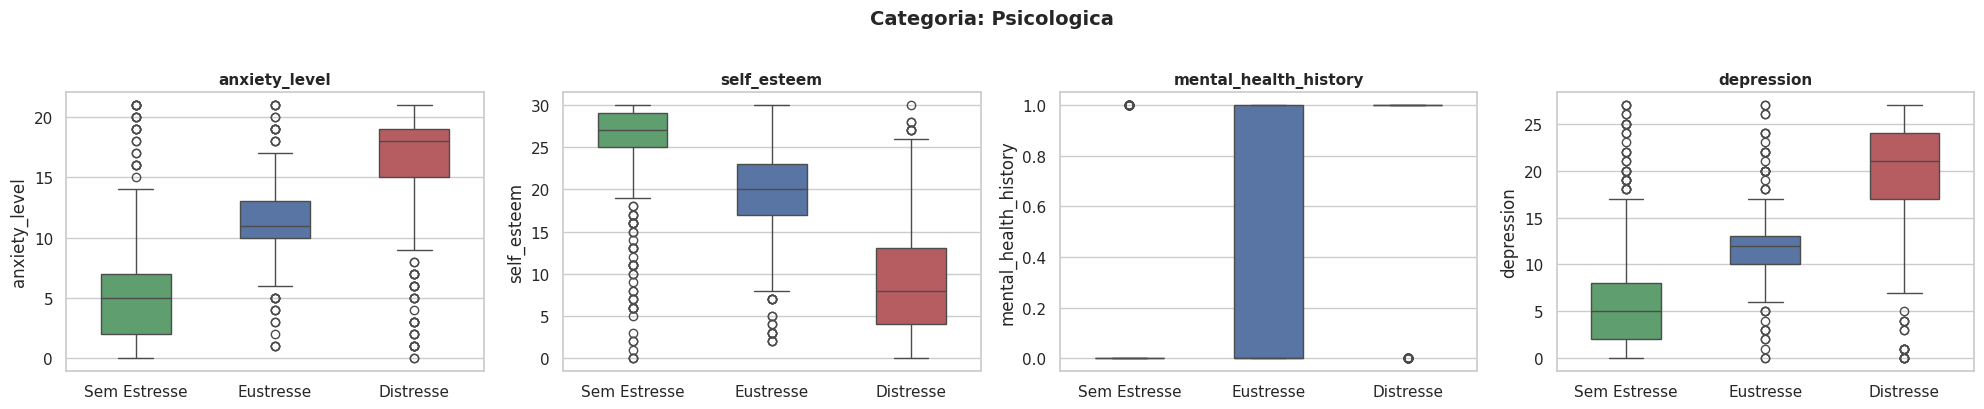

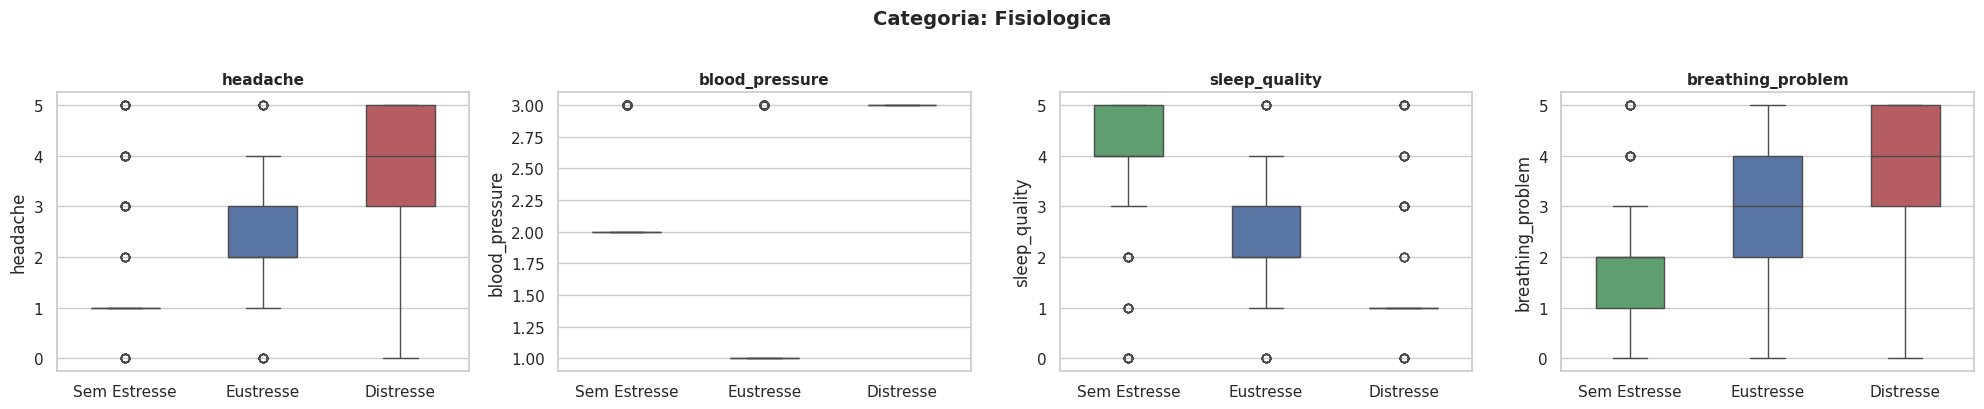

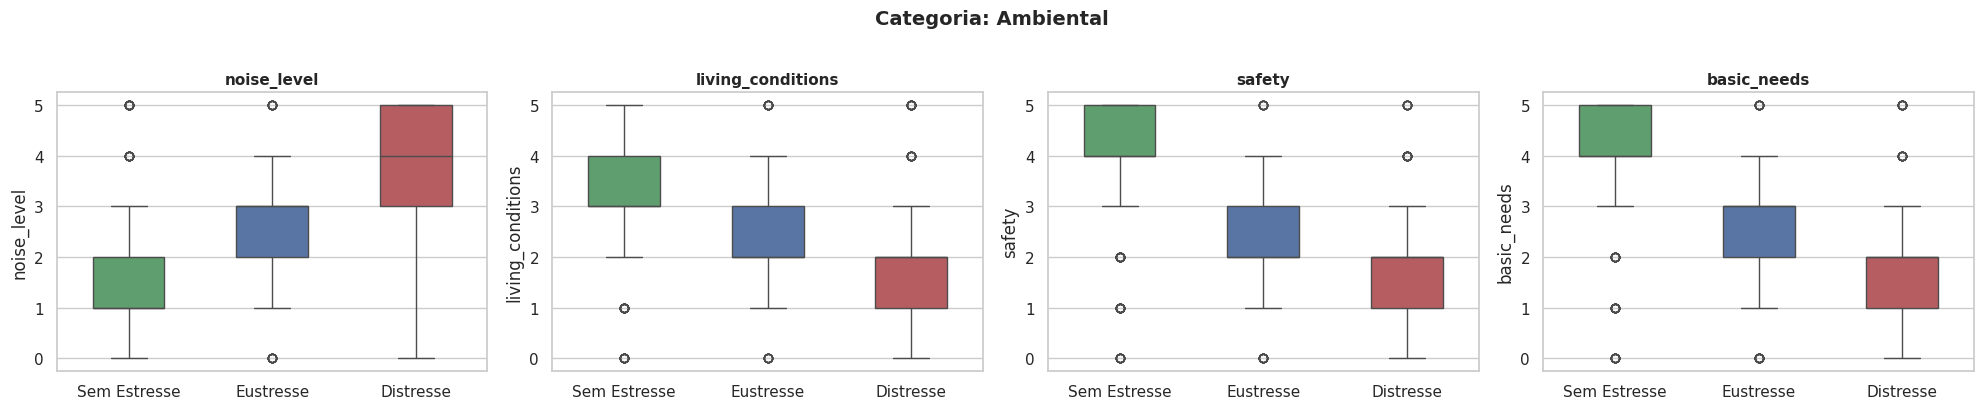

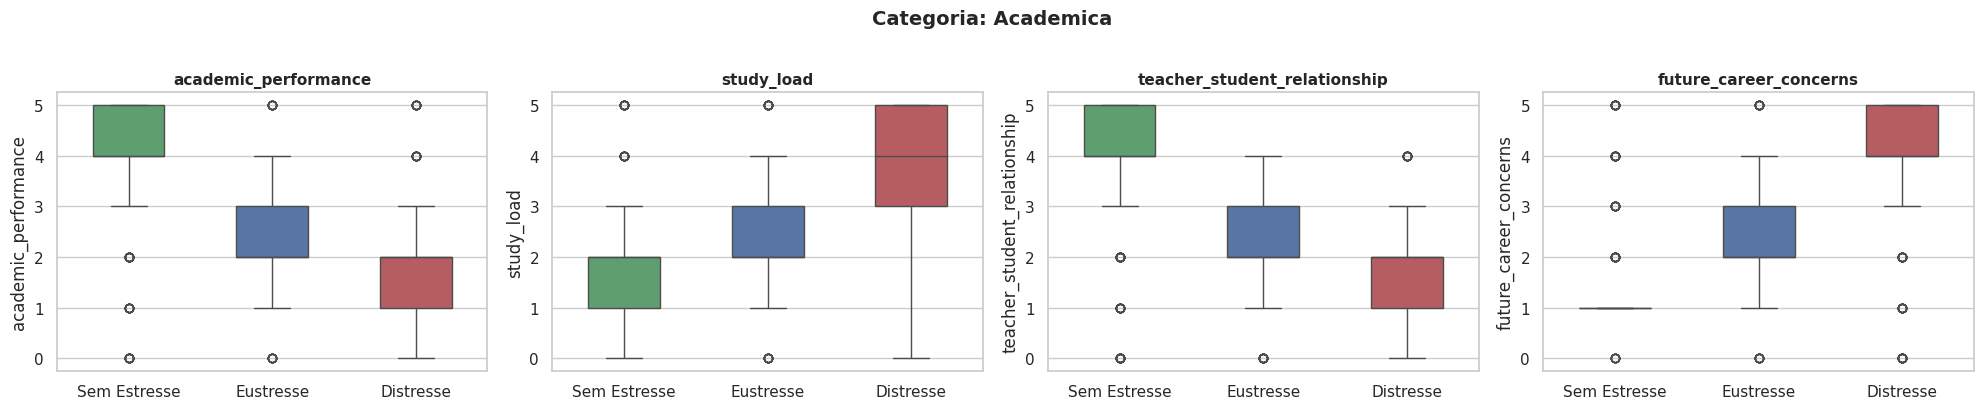

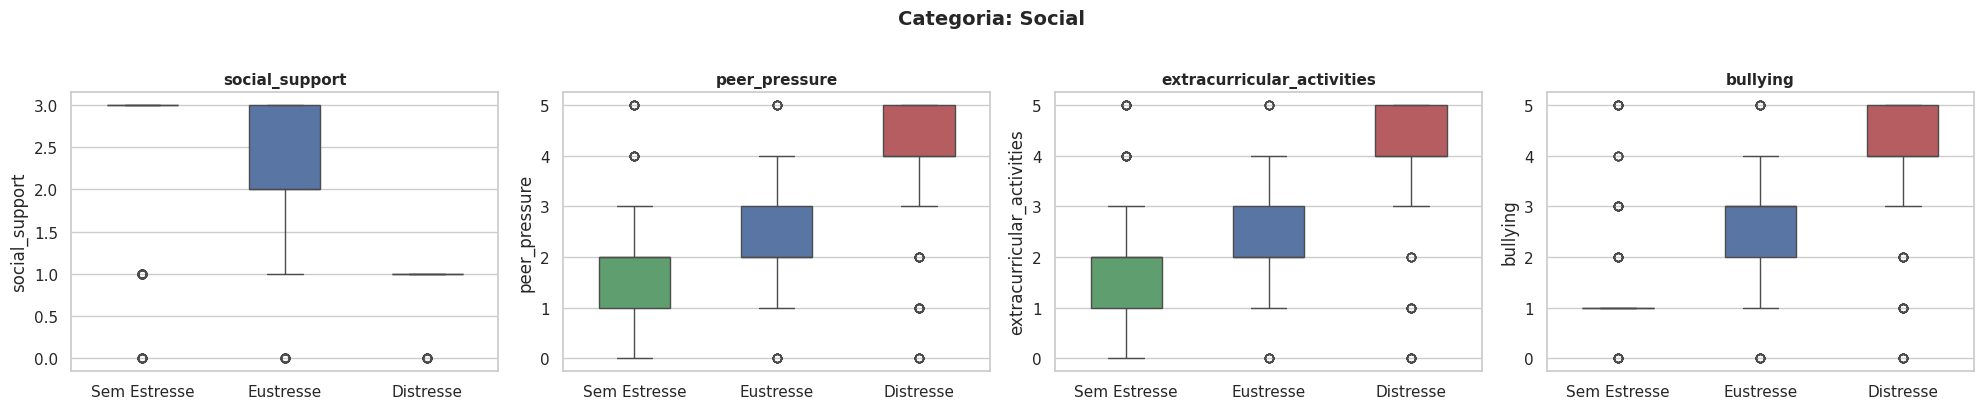

In [30]:
# ============================================================
# CELULA 8 — Distribuicao das features por categoria
# ============================================================

for cat_nome, cat_feats in categorias.items():
    fig, axes = plt.subplots(1, len(cat_feats), figsize=(5*len(cat_feats), 4))
    fig.suptitle(f'Categoria: {cat_nome}', fontsize=14, fontweight='bold', y=1.02)

    if len(cat_feats) == 1:
        axes = [axes]   # garante que axes seja iteravel

    for ax, feat in zip(axes, cat_feats):
        # boxplot separado por nivel de estresse
        sns.boxplot(data=df, x='stress_nome', y=feat, palette=cores_stress,
                    order=['Sem Estresse', 'Eustresse', 'Distresse'],
                    ax=ax, width=0.5)
        ax.set_title(feat, fontsize=11, fontweight='bold')
        ax.set_xlabel('')

    plt.tight_layout()
    plt.show()


In [31]:
# ============================================================
# CELULA 9 — Analise de outliers
# ============================================================

print("=== Contagem de Outliers por Feature (regra IQR) ===\n")

resultados_outlier = []
for feat in features:
    Q1 = df[feat].quantile(0.25)     # primeiro quartil
    Q3 = df[feat].quantile(0.75)     # terceiro quartil
    IQR = Q3 - Q1                    # amplitude interquartil
    lim_inf = Q1 - 1.5 * IQR        # limite inferior
    lim_sup = Q3 + 1.5 * IQR        # limite superior
    n_out = df[(df[feat] < lim_inf) | (df[feat] > lim_sup)].shape[0]
    pct = round(n_out / len(df) * 100, 1)
    resultados_outlier.append({'Feature': feat, 'Outliers': n_out, '%': f'{pct}%'})

df_out = pd.DataFrame(resultados_outlier)
display(df_out)
print(f"\nSoma total de outliers: {df_out['Outliers'].sum()}")
print("Manteremos todos — dataset pequeno, nao podemos perder informacao.")

=== Contagem de Outliers por Feature (regra IQR) ===



,Feature,Outliers,%
0,anxiety_level,0,0.0%
1,self_esteem,0,0.0%
2,mental_health_history,0,0.0%
3,depression,0,0.0%
4,headache,0,0.0%
5,blood_pressure,0,0.0%
6,sleep_quality,0,0.0%
7,breathing_problem,0,0.0%
8,noise_level,173,15.7%
9,living_conditions,62,5.6%



Soma total de outliers: 400
Manteremos todos — dataset pequeno, nao podemos perder informacao.


  ANALISE DESCRITIVA
  'O que aconteceu? Qual e o cenario atual?'

=== 1. Perfil Medio por Grupo de Estresse ===



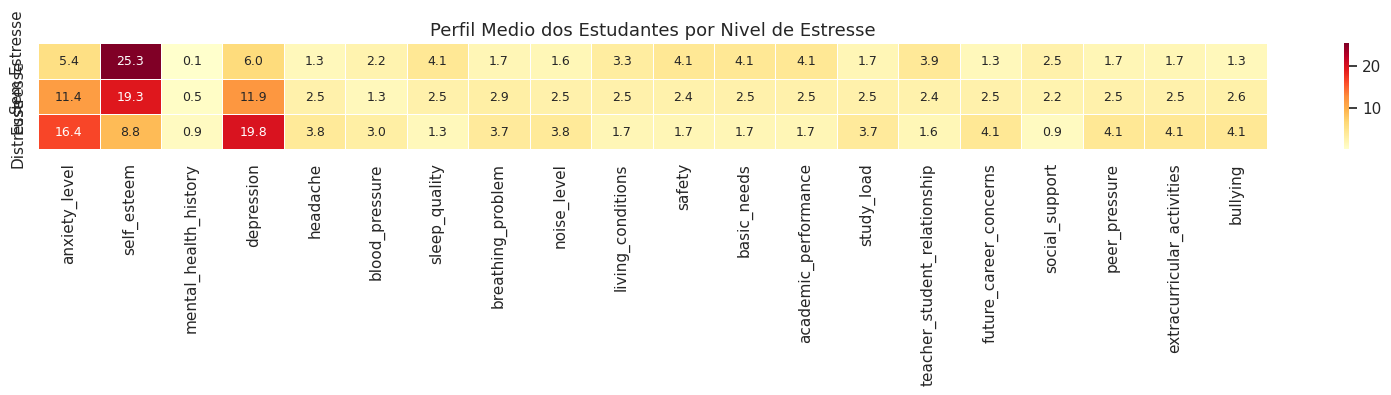

=== 2. Comparacao Radar dos 3 Perfis ===



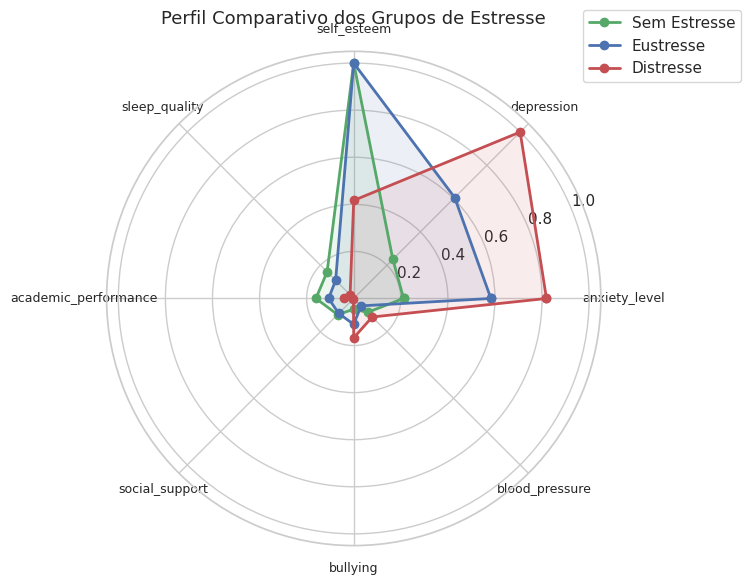

=== 3. Score Medio por Categoria ===



Categoria,Academica,Ambiental,Fisiologica,Psicologica,Social
Nivel,,,,,
Distresse,2.77,2.22,2.93,11.48,3.29
Eustresse,2.48,2.48,2.31,10.76,2.42
Sem Estresse,2.76,3.30,2.33,9.20,1.80


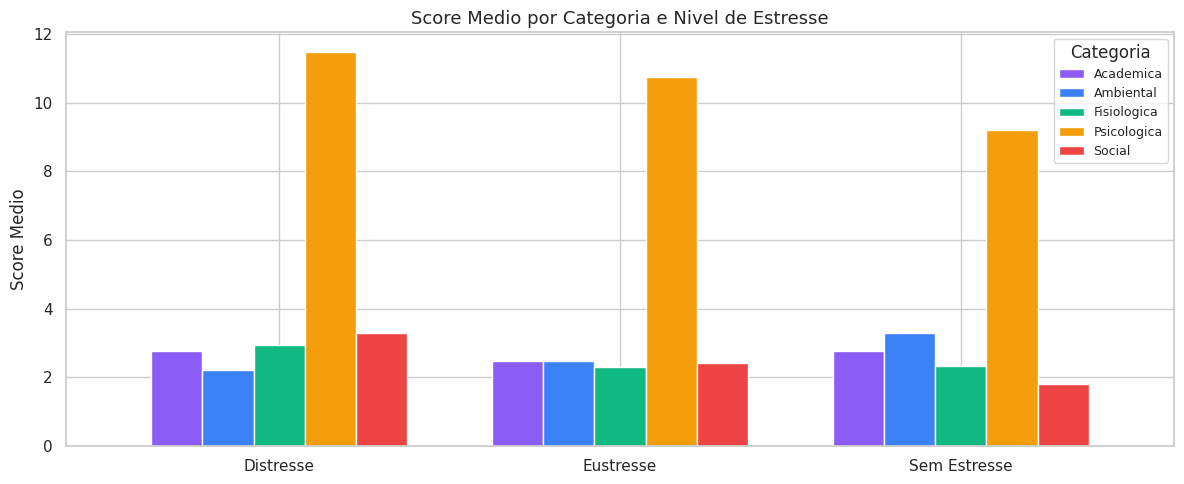

=== 4. Padroes Descritivos Identificados ===

Correlacao entre categorias e nivel de estresse:
  Psicologica    +0.429  ############
  Fisiologica    +0.478  ##############
  Ambiental      -0.655  ###################
  Academica      +0.005  
  Social         +0.745  ######################

RESUMO DESCRITIVO:
  - 1100 estudantes analisados
  - 369 (33.5%) apresentam distresse
  - Estudantes com distresse tem ansiedade 16x maior
    que estudantes sem estresse (5)
  - Depressao media no grupo distresse: 19.8
    vs 6.0 no grupo sem estresse
  - Autoestima e inversamente proporcional ao estresse:
    Sem Estresse=25.3,
    Distresse=8.8



In [32]:
print("=" * 60)
print("  ANALISE DESCRITIVA")
print("  'O que aconteceu? Qual e o cenario atual?'")
print("=" * 60)

# 1. Perfil medio de cada grupo de estresse
print("\n=== 1. Perfil Medio por Grupo de Estresse ===\n")

# calcula a media de cada feature para cada nivel de estresse
perfil = df.groupby('stress_level')[features].mean()
perfil.index = ['Sem Estresse', 'Eustresse', 'Distresse']

# heatmap do perfil — mostra visualmente onde cada grupo se destaca
fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(perfil.round(1), annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Perfil Medio dos Estudantes por Nivel de Estresse', fontsize=13)
ax.set_ylabel('')
plt.tight_layout()
plt.show()

# 2. Radar chart comparando os 3 perfis
print("=== 2. Comparacao Radar dos 3 Perfis ===\n")

# normaliza os valores entre 0 e 1 para o radar ficar proporcional
from sklearn.preprocessing import MinMaxScaler
perfil_norm = pd.DataFrame(
    MinMaxScaler().fit_transform(perfil.T).T,
    columns=features, index=perfil.index
)

# seleciona as 8 features mais relevantes para o radar nao ficar poluido
top_feats = ['anxiety_level', 'depression', 'self_esteem', 'sleep_quality',
             'academic_performance', 'social_support', 'bullying', 'blood_pressure']

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
angulos = np.linspace(0, 2*np.pi, len(top_feats), endpoint=False).tolist()
angulos += angulos[:1]  # fecha o poligono

for grupo, cor in zip(perfil_norm.index, ['#55A868', '#4C72B0', '#C44E52']):
    valores = perfil_norm.loc[grupo, top_feats].values.tolist()
    valores += valores[:1]  # fecha o poligono
    ax.plot(angulos, valores, 'o-', linewidth=2, label=grupo, color=cor)
    ax.fill(angulos, valores, alpha=0.1, color=cor)

ax.set_xticks(angulos[:-1])
ax.set_xticklabels(top_feats, fontsize=9)
ax.set_title('Perfil Comparativo dos Grupos de Estresse', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

# 3. Distribuicao por categoria
print("=== 3. Score Medio por Categoria ===\n")

scores_cat = {}
for cat_nome, cat_feats in categorias.items():
    for nivel in [0, 1, 2]:
        media = df[df['stress_level'] == nivel][cat_feats].mean().mean()
        scores_cat[(mapa_estresse[nivel], cat_nome)] = round(media, 2)

df_scores = pd.DataFrame.from_dict(scores_cat, orient='index', columns=['Score Medio'])
df_scores.index = pd.MultiIndex.from_tuples(df_scores.index, names=['Nivel', 'Categoria'])
df_scores = df_scores.unstack()
df_scores.columns = df_scores.columns.droplevel(0)
display(df_scores)

# grafico de barras agrupadas por categoria
fig, ax = plt.subplots(figsize=(12, 5))
df_scores.plot(kind='bar', ax=ax, color=['#8B5CF6', '#3B82F6', '#10B981', '#F59E0B', '#EF4444'],
               edgecolor='white', width=0.75)
ax.set_title('Score Medio por Categoria e Nivel de Estresse', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Score Medio')
ax.set_xticklabels(df_scores.index, rotation=0)
ax.legend(title='Categoria', fontsize=9)
plt.tight_layout()
plt.show()

# 4. Correlacoes cruzadas entre categorias
print("=== 4. Padroes Descritivos Identificados ===\n")

# calcula correlacoes entre categorias (media de cada categoria)
cat_means = pd.DataFrame()
for cat_nome, cat_feats in categorias.items():
    cat_means[cat_nome] = df[cat_feats].mean(axis=1)
cat_means['stress_level'] = df['stress_level']

print("Correlacao entre categorias e nivel de estresse:")
for cat_nome in categorias:
    corr_val = cat_means[cat_nome].corr(cat_means['stress_level'])
    barra = '#' * int(abs(corr_val) * 30)
    sinal = '+' if corr_val > 0 else '-'
    print(f"  {cat_nome:<14} {sinal}{abs(corr_val):.3f}  {barra}")

# resumo descritivo
print(f"""
RESUMO DESCRITIVO:
  - {len(df)} estudantes analisados
  - {(df['stress_level']==2).sum()} ({(df['stress_level']==2).sum()/len(df)*100:.1f}%) apresentam distresse
  - Estudantes com distresse tem ansiedade {perfil.loc['Distresse','anxiety_level']:.0f}x maior
    que estudantes sem estresse ({perfil.loc['Sem Estresse','anxiety_level']:.0f})
  - Depressao media no grupo distresse: {perfil.loc['Distresse','depression']:.1f}
    vs {perfil.loc['Sem Estresse','depression']:.1f} no grupo sem estresse
  - Autoestima e inversamente proporcional ao estresse:
    Sem Estresse={perfil.loc['Sem Estresse','self_esteem']:.1f},
    Distresse={perfil.loc['Distresse','self_esteem']:.1f}
""")

In [33]:
# ============================================================
# CELULA 10 — Separacao features/target e divisao treino/teste
# ============================================================

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler

# separa features (X) e target (y)
X = df[features]                  # 20 features
y = df['stress_level']            # variavel alvo (0, 1, 2)

# divide 80% treino / 20% teste com estratificacao
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% para teste
    random_state=42,      # seed fixa
    stratify=y            # mantem proporcao das 3 classes
)

print(f"Treino: {X_train.shape[0]} amostras ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Teste:  {X_test.shape[0]} amostras ({X_test.shape[0]/len(X)*100:.0f}%)")

print(f"\nBalanceamento no treino:")
print(y_train.value_counts().sort_index())
print(f"\nBalanceamento no teste:")
print(y_test.value_counts().sort_index())


Treino: 880 amostras (80%)
Teste:  220 amostras (20%)

Balanceamento no treino:
stress_level
0    299
1    286
2    295
Name: count, dtype: int64

Balanceamento no teste:
stress_level
0    74
1    72
2    74
Name: count, dtype: int64


In [34]:
# ============================================================
# CELULA 11 — Padronizacao (StandardScaler)
# ============================================================

# cria o objeto de padronizacao
scaler = StandardScaler()

# fit_transform no treino — aprende media e desvio E aplica
X_train_scaled = scaler.fit_transform(X_train)
# transform no teste — aplica a mesma escala sem reaprender
X_test_scaled = scaler.transform(X_test)

# converte de volta para DataFrame para manter nomes das colunas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=features)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=features)

print("Padronizacao aplicada.")
print(f"  Media no treino (deve ser ~0): {X_train_scaled.mean().mean():.6f}")
print(f"  Desvio no treino (deve ser ~1): {X_train_scaled.std().mean():.4f}")

# configura validacao cruzada estratificada com 5 folds
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f"\nValidacao cruzada: StratifiedKFold(5 folds, seed=42)")



Padronizacao aplicada.
  Media no treino (deve ser ~0): -0.000000
  Desvio no treino (deve ser ~1): 1.0006

Validacao cruzada: StratifiedKFold(5 folds, seed=42)


=== Treinamento dos Modelos (Validacao Cruzada 5-fold) ===

  Baseline (Dummy)          F1= 16.91%  Acc= 33.98%  Gap=+0.0% (sem overfitting)
  Regressao Logistica       F1= 87.74%  Acc= 87.73%  Gap=+3.2% (sem overfitting)
  Random Forest             F1= 86.95%  Acc= 86.93%  Gap=+13.1% (possivel overfitting)
  SVM (RBF)                 F1= 86.70%  Acc= 86.70%  Gap=+12.4% (possivel overfitting)
  XGBoost                   F1= 87.73%  Acc= 87.73%  Gap=+12.3% (possivel overfitting)

=== Tabela Comparativa ===



,Acuracia Val (%),F1-Macro Val (%),Precisao Val (%),Recall Val (%),Acuracia Treino (%),F1 Std (+/-)
Regressao Logistica,87.73,87.74,87.99,87.71,90.91,2.81
XGBoost,87.73,87.73,87.85,87.72,100.00,2.33
Random Forest,86.93,86.95,87.41,86.92,100.00,2.49
SVM (RBF),86.70,86.70,87.16,86.69,99.09,2.84
Baseline (Dummy),33.98,16.91,11.33,33.33,33.98,0.08


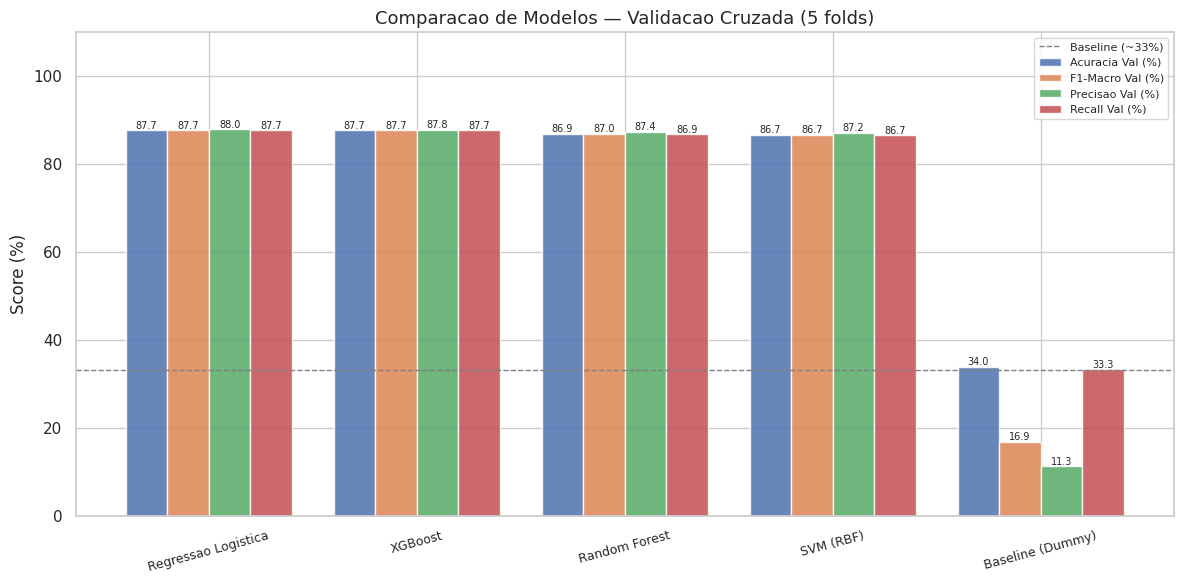

In [35]:
# ============================================================
# CELULA 12 — Treinamento e comparacao de modelos
# ============================================================

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, classification_report,
                             confusion_matrix)

# dicionario para guardar resultados
resultados = {}

# funcao que avalia qualquer modelo com cross-validation
def avaliar(nome, modelo, X_tr, y_tr):
    scores = cross_validate(
        modelo, X_tr, y_tr, cv=cv,
        scoring={'accuracy':'accuracy', 'f1':'f1_macro',
                 'precision':'precision_macro', 'recall':'recall_macro'},
        return_train_score=True
    )
    r = {
        'Acuracia Val (%)': round(scores['test_accuracy'].mean()*100, 2),
        'F1-Macro Val (%)': round(scores['test_f1'].mean()*100, 2),
        'Precisao Val (%)': round(scores['test_precision'].mean()*100, 2),
        'Recall Val (%)':   round(scores['test_recall'].mean()*100, 2),
        'Acuracia Treino (%)': round(scores['train_accuracy'].mean()*100, 2),
        'F1 Std (+/-)':     round(scores['test_f1'].std()*100, 2),
    }
    resultados[nome] = r
    gap = r['Acuracia Treino (%)'] - r['Acuracia Val (%)']
    status = "possivel overfitting" if gap > 5 else "sem overfitting"
    print(f"  {nome:<25} F1={r['F1-Macro Val (%)']:>6.2f}%  "
          f"Acc={r['Acuracia Val (%)']:>6.2f}%  "
          f"Gap={gap:+.1f}% ({status})")
    return scores

print("=== Treinamento dos Modelos (Validacao Cruzada 5-fold) ===\n")

# 1. Baseline — chuta a classe mais frequente (piso de comparacao)
avaliar('Baseline (Dummy)',
        DummyClassifier(strategy='most_frequent', random_state=42),
        X_train_scaled, y_train)

# 2. Regressao Logistica — modelo linear multiclasse
avaliar('Regressao Logistica',
        LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial'),
        X_train_scaled, y_train)

# 3. Random Forest — ensemble de arvores
avaliar('Random Forest',
        RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
        X_train_scaled, y_train)

# 4. SVM — maquina de vetores de suporte com kernel RBF
avaliar('SVM (RBF)',
        SVC(kernel='rbf', random_state=42, probability=True),
        X_train_scaled, y_train)

# 5. XGBoost — gradient boosting (normalmente o mais forte)
avaliar('XGBoost',
        XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                      random_state=42, eval_metric='mlogloss',
                      use_label_encoder=False),
        X_train_scaled, y_train)

# tabela comparativa
print("\n=== Tabela Comparativa ===\n")
df_res = pd.DataFrame(resultados).T.sort_values('F1-Macro Val (%)', ascending=False)
display(df_res)

# grafico comparativo
fig, ax = plt.subplots(figsize=(12, 6))
modelos = df_res.index.tolist()
x = np.arange(len(modelos))
metricas = ['Acuracia Val (%)', 'F1-Macro Val (%)', 'Precisao Val (%)', 'Recall Val (%)']
cores_m = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
larg = 0.2
for i, (met, cor) in enumerate(zip(metricas, cores_m)):
    vals = df_res[met].values
    bars = ax.bar(x + i*larg, vals, larg, label=met, color=cor, alpha=0.85)
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
                f'{b.get_height():.1f}', ha='center', fontsize=7)
ax.axhline(y=33.3, color='gray', linestyle='--', linewidth=1, label='Baseline (~33%)')
ax.set_xticks(x + larg*1.5)
ax.set_xticklabels(modelos, fontsize=9, rotation=15)
ax.set_ylabel('Score (%)')
ax.set_title('Comparacao de Modelos — Validacao Cruzada (5 folds)', fontsize=13)
ax.set_ylim(0, 110)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()



In [36]:
# ============================================================
# CELULA 13 — Otimizacao de hiperparametros
# ============================================================

from sklearn.model_selection import GridSearchCV

print("=== Otimizacao de Hiperparametros (GridSearchCV) ===\n")

# otimiza os dois melhores modelos (tipicamente RF e XGBoost)

# --- Random Forest ---
print(">>> Otimizando Random Forest...")
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid={
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5, 10]
    },
    cv=cv, scoring='f1_macro', n_jobs=-1
)
grid_rf.fit(X_train_scaled, y_train)
print(f"  Melhores params: {grid_rf.best_params_}")
print(f"  F1-Macro (val): {grid_rf.best_score_*100:.2f}%")

# --- XGBoost ---
print("\n>>> Otimizando XGBoost...")
grid_xgb = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False),
    param_grid={
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 4, 6],
        'learning_rate': [0.01, 0.1, 0.2]
    },
    cv=cv, scoring='f1_macro', n_jobs=-1
)
grid_xgb.fit(X_train_scaled, y_train)
print(f"  Melhores params: {grid_xgb.best_params_}")
print(f"  F1-Macro (val): {grid_xgb.best_score_*100:.2f}%")

# --- Regressao Logistica ---
print("\n>>> Otimizando Regressao Logistica...")
grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial'),
    param_grid={
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l2']
    },
    cv=cv, scoring='f1_macro', n_jobs=-1
)
grid_lr.fit(X_train_scaled, y_train)
print(f"  Melhores params: {grid_lr.best_params_}")
print(f"  F1-Macro (val): {grid_lr.best_score_*100:.2f}%")

# tabela comparativa pos-otimizacao
print("\n=== Comparacao Pos-Otimizacao ===")
otim = {
    'Random Forest':        grid_rf.best_score_*100,
    'XGBoost':              grid_xgb.best_score_*100,
    'Regressao Logistica':  grid_lr.best_score_*100
}
for nome, score in sorted(otim.items(), key=lambda x: x[1], reverse=True):
    print(f"  {nome:<25} F1-Macro: {score:.2f}%")



=== Otimizacao de Hiperparametros (GridSearchCV) ===

>>> Otimizando Random Forest...
  Melhores params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
  F1-Macro (val): 88.19%

>>> Otimizando XGBoost...
  Melhores params: {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 200}
  F1-Macro (val): 88.99%

>>> Otimizando Regressao Logistica...
  Melhores params: {'C': 0.1, 'penalty': 'l2'}
  F1-Macro (val): 88.33%

=== Comparacao Pos-Otimizacao ===
  XGBoost                   F1-Macro: 88.99%
  Regressao Logistica       F1-Macro: 88.33%
  Random Forest             F1-Macro: 88.19%


In [37]:
# ============================================================
# CELULA 14 — Avaliacao final no conjunto de teste
# ============================================================

print("=== Avaliacao Final no Conjunto de Teste ===\n")

# seleciona os 3 modelos otimizados
modelos_finais = {
    'Regressao Logistica': grid_lr.best_estimator_,
    'Random Forest':       grid_rf.best_estimator_,
    'XGBoost':             grid_xgb.best_estimator_,
}

linhas = []
for nome, mod in modelos_finais.items():
    pred = mod.predict(X_test_scaled)
    linhas.append({
        'Modelo': nome,
        'Acuracia (%)': round(accuracy_score(y_test, pred)*100, 2),
        'F1-Macro (%)': round(f1_score(y_test, pred, average='macro')*100, 2),
        'Precisao (%)': round(precision_score(y_test, pred, average='macro')*100, 2),
        'Recall (%)':   round(recall_score(y_test, pred, average='macro')*100, 2),
    })

df_teste = pd.DataFrame(linhas).set_index('Modelo').sort_values('F1-Macro (%)', ascending=False)
display(df_teste)

melhor_nome = df_teste['F1-Macro (%)'].idxmax()
melhor_modelo = modelos_finais[melhor_nome]
print(f"\nMelhor modelo no teste: {melhor_nome}")
print(f"F1-Macro: {df_teste.loc[melhor_nome, 'F1-Macro (%)']:.2f}%")

=== Avaliacao Final no Conjunto de Teste ===



,Acuracia (%),F1-Macro (%),Precisao (%),Recall (%)
Modelo,,,,
Regressao Logistica,88.64,88.68,88.70,88.66
Random Forest,88.64,88.61,88.83,88.68
XGBoost,87.27,87.26,87.34,87.30



Melhor modelo no teste: Regressao Logistica
F1-Macro: 88.68%


=== Relatorio de Classificacao — Regressao Logistica ===

              precision    recall  f1-score   support

Sem Estresse       0.85      0.85      0.85        74
   Eustresse       0.93      0.92      0.92        72
   Distresse       0.88      0.89      0.89        74

    accuracy                           0.89       220
   macro avg       0.89      0.89      0.89       220
weighted avg       0.89      0.89      0.89       220



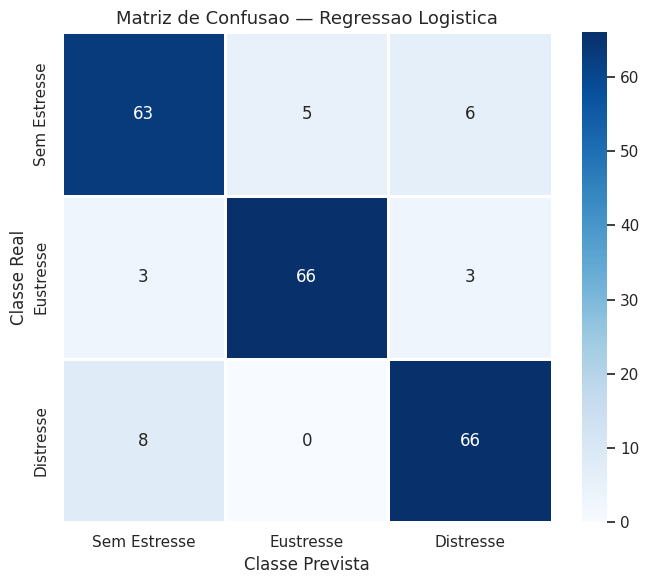

Total de erros: 25 de 220 (11.4%)


In [38]:
# ============================================================
# CELULA 15 — Relatorio de classificacao e matriz de confusao
# ============================================================

# predicoes do melhor modelo
y_pred = melhor_modelo.predict(X_test_scaled)

print(f"=== Relatorio de Classificacao — {melhor_nome} ===\n")
print(classification_report(y_test, y_pred,
      target_names=['Sem Estresse', 'Eustresse', 'Distresse']))

# matriz de confusao
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sem Estresse', 'Eustresse', 'Distresse'],
            yticklabels=['Sem Estresse', 'Eustresse', 'Distresse'],
            linewidths=1, ax=ax)
ax.set_xlabel('Classe Prevista', fontsize=12)
ax.set_ylabel('Classe Real', fontsize=12)
ax.set_title(f'Matriz de Confusao — {melhor_nome}', fontsize=13)
plt.tight_layout()
plt.show()

# contagem de erros
total_erros = (y_test != y_pred).sum()
print(f"Total de erros: {total_erros} de {len(y_test)} ({total_erros/len(y_test)*100:.1f}%)")


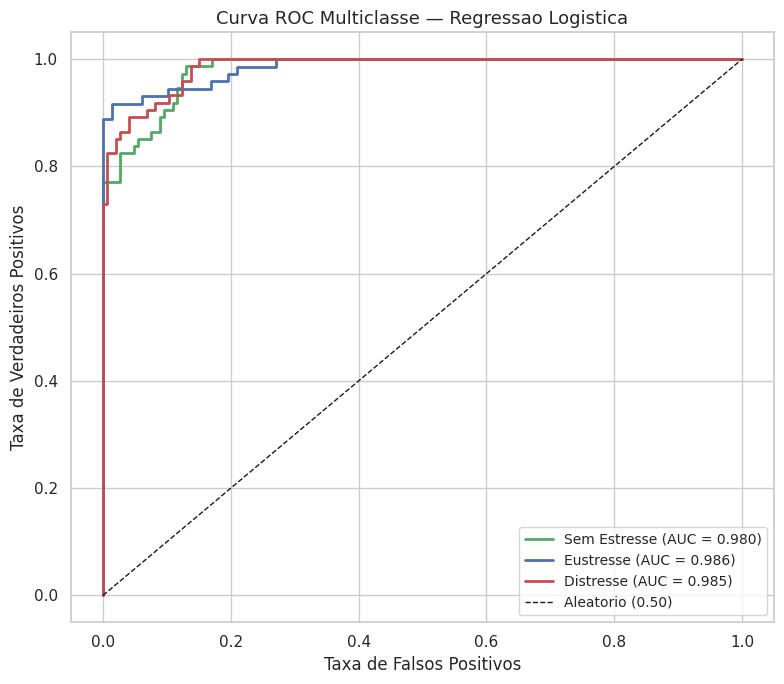

In [39]:
# ============================================================
# CELULA 16 — Curva ROC multiclasse
# ============================================================

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# binariza as classes para ROC multiclasse (one-vs-rest)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_proba = melhor_modelo.predict_proba(X_test_scaled)

fig, ax = plt.subplots(figsize=(8, 7))
cores_roc = ['#55A868', '#4C72B0', '#C44E52']
nomes_classes = ['Sem Estresse', 'Eustresse', 'Distresse']

for i, (nome_c, cor) in enumerate(zip(nomes_classes, cores_roc)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=cor, linewidth=2,
            label=f'{nome_c} (AUC = {roc_auc:.3f})')

ax.plot([0,1], [0,1], 'k--', linewidth=1, label='Aleatorio (0.50)')
ax.set_xlabel('Taxa de Falsos Positivos', fontsize=12)
ax.set_ylabel('Taxa de Verdadeiros Positivos', fontsize=12)
ax.set_title(f'Curva ROC Multiclasse — {melhor_nome}', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


  ANALISE PREDITIVA
  'O que vai acontecer? Quais sao os riscos?'

=== 1. Mapa de Risco da Turma (Conjunto de Teste) ===

Primeiros 10 estudantes com suas probabilidades:


,P(Sem Estresse),P(Eustresse),P(Distresse),Classe Prevista,Classe Real,Risco Distresse (%),Confianca (%)
0,0.967989,0.031564,0.000447,0,0,0.0,96.8
1,0.981028,0.018718,0.000253,0,0,0.0,98.1
2,0.003317,0.029119,0.967564,2,2,96.8,96.8
3,0.002913,0.044016,0.953071,2,2,95.3,95.3
4,0.261612,0.238288,0.500100,2,0,50.0,50.0
5,0.974879,0.024806,0.000316,0,0,0.0,97.5
6,0.000766,0.016739,0.982495,2,2,98.2,98.2
7,0.056350,0.415632,0.528018,2,0,52.8,52.8
8,0.009654,0.983387,0.006959,1,1,0.7,98.3
9,0.717970,0.151142,0.130889,0,0,13.1,71.8


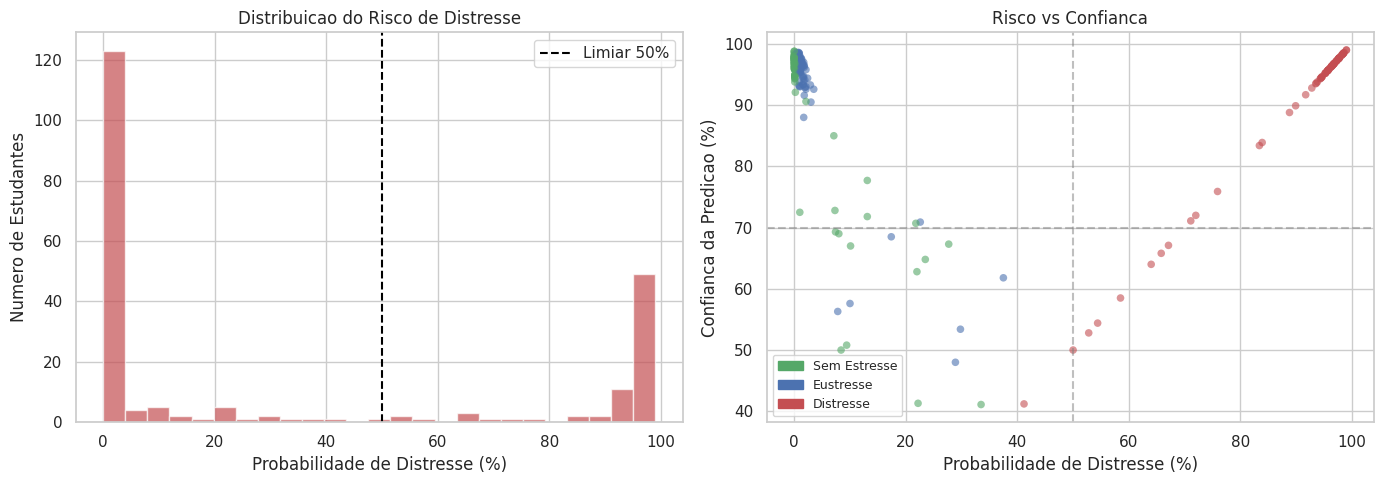

=== 2. Classificacao em Faixas de Risco ===

  BAIXO       143 estudantes ( 65.0%)  #################################################################
  MODERADO      3 estudantes (  1.4%)  #
  ALTO          7 estudantes (  3.2%)  ###
  CRITICO      67 estudantes ( 30.5%)  ##############################


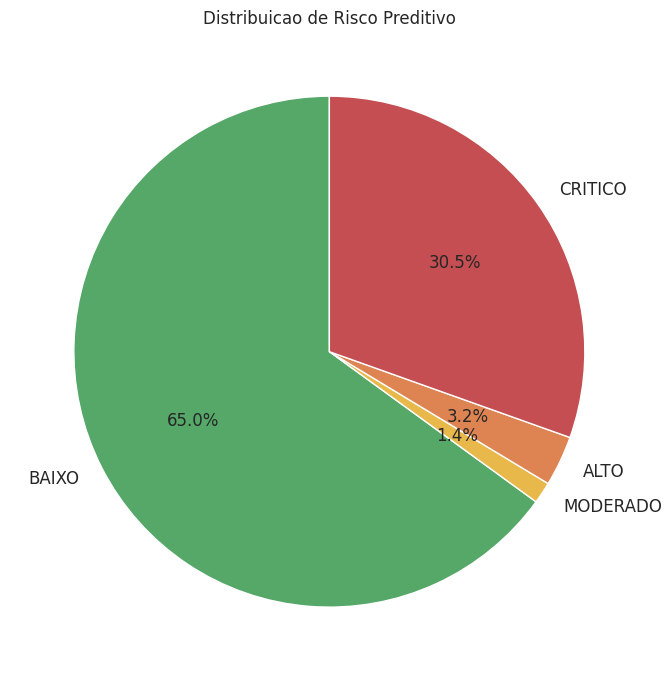

=== 3. Analise de Cenarios ('E se...?') ===

Estudante com maior risco de distresse: 99.0%

Simulacao: o que acontece se melhorarmos cada fator?



,Cenario,Risco Original (%),Risco Novo (%),Reducao (p.p.)
4,Melhorar desempenho academico,99.0,96.9,2.0
2,Eliminar depressao,99.0,97.3,1.6
6,Eliminar bullying,99.0,97.8,1.2
3,Maximizar qualidade do sono,99.0,97.8,1.1
1,Dobrar autoestima,99.0,99.0,0.0
5,Maximizar suporte social,99.0,99.1,-0.1
0,Reduzir ansiedade pela metade,99.0,99.2,-0.2


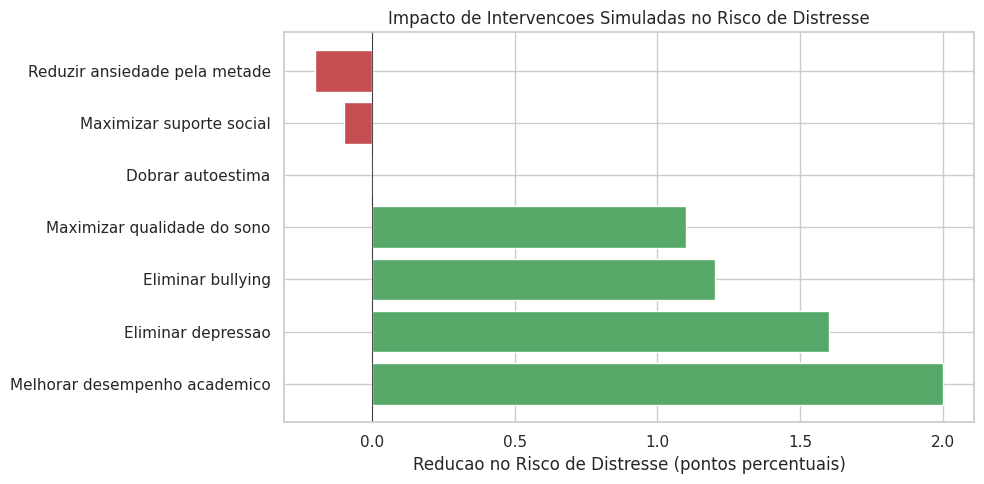


Intervencao mais efetiva: Melhorar desempenho academico
  Reducao de 2.0 pontos percentuais no risco


In [40]:
print("=" * 60)
print("  ANALISE PREDITIVA")
print("  'O que vai acontecer? Quais sao os riscos?'")
print("=" * 60)

# 1. Mapa de probabilidades de toda a turma
print("\n=== 1. Mapa de Risco da Turma (Conjunto de Teste) ===\n")

# gera probabilidades para todos os estudantes do teste
probas_teste = melhor_modelo.predict_proba(X_test_scaled)

# cria DataFrame com as probabilidades
df_probas = pd.DataFrame(probas_teste,
    columns=['P(Sem Estresse)', 'P(Eustresse)', 'P(Distresse)'])
df_probas['Classe Prevista'] = y_pred
df_probas['Classe Real'] = y_test.values
df_probas['Risco Distresse (%)'] = (probas_teste[:, 2] * 100).round(1)
df_probas['Confianca (%)'] = (probas_teste.max(axis=1) * 100).round(1)

print("Primeiros 10 estudantes com suas probabilidades:")
display(df_probas.head(10))

# 2. Distribuicao do risco de distresse
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histograma da probabilidade de distresse
axes[0].hist(df_probas['Risco Distresse (%)'], bins=25, color='#C44E52',
             alpha=0.7, edgecolor='white')
axes[0].axvline(50, color='black', linestyle='--', linewidth=1.5, label='Limiar 50%')
axes[0].set_xlabel('Probabilidade de Distresse (%)')
axes[0].set_ylabel('Numero de Estudantes')
axes[0].set_title('Distribuicao do Risco de Distresse')
axes[0].legend()

# scatter: risco de distresse vs confianca
cores_scatter = ['#55A868' if c==0 else '#4C72B0' if c==1 else '#C44E52'
                 for c in df_probas['Classe Prevista']]
axes[1].scatter(df_probas['Risco Distresse (%)'], df_probas['Confianca (%)'],
                c=cores_scatter, alpha=0.6, s=30, edgecolors='none')
axes[1].set_xlabel('Probabilidade de Distresse (%)')
axes[1].set_ylabel('Confianca da Predicao (%)')
axes[1].set_title('Risco vs Confianca')
axes[1].axvline(50, color='gray', linestyle='--', alpha=0.5)
axes[1].axhline(70, color='gray', linestyle='--', alpha=0.5)

# legenda manual
from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(color='#55A868', label='Sem Estresse'),
    Patch(color='#4C72B0', label='Eustresse'),
    Patch(color='#C44E52', label='Distresse')
], fontsize=9)

plt.tight_layout()
plt.show()

# 3. Faixas de risco
print("=== 2. Classificacao em Faixas de Risco ===\n")

def faixa_risco(prob_distresse):
    if prob_distresse >= 70:
        return 'CRITICO'
    elif prob_distresse >= 50:
        return 'ALTO'
    elif prob_distresse >= 30:
        return 'MODERADO'
    else:
        return 'BAIXO'

df_probas['Faixa de Risco'] = df_probas['Risco Distresse (%)'].apply(faixa_risco)

faixas = df_probas['Faixa de Risco'].value_counts()
cores_faixa = {'BAIXO': '#55A868', 'MODERADO': '#E8B84B', 'ALTO': '#DD8452', 'CRITICO': '#C44E52'}

for faixa in ['BAIXO', 'MODERADO', 'ALTO', 'CRITICO']:
    n = faixas.get(faixa, 0)
    pct = n / len(df_probas) * 100
    barra = '#' * int(pct)
    print(f"  {faixa:<10} {n:>4} estudantes ({pct:>5.1f}%)  {barra}")

# grafico de pizza das faixas
fig, ax = plt.subplots(figsize=(7, 7))
faixas_order = ['BAIXO', 'MODERADO', 'ALTO', 'CRITICO']
vals = [faixas.get(f, 0) for f in faixas_order]
cors = [cores_faixa[f] for f in faixas_order]
ax.pie(vals, labels=faixas_order, autopct='%1.1f%%', colors=cors,
       startangle=90, textprops={'fontsize': 12})
ax.set_title('Distribuicao de Risco Preditivo')
plt.tight_layout()
plt.show()

# 4. Analise de cenarios: "e se" mudassemos uma variavel
print("=== 3. Analise de Cenarios ('E se...?') ===\n")

# pega um estudante de alto risco como exemplo
idx_alto_risco = df_probas['Risco Distresse (%)'].idxmax()
estudante_original = X_test.iloc[idx_alto_risco].values.copy()
prob_original = probas_teste[idx_alto_risco, 2] * 100

print(f"Estudante com maior risco de distresse: {prob_original:.1f}%\n")
print("Simulacao: o que acontece se melhorarmos cada fator?\n")

cenarios = {
    'Reduzir ansiedade pela metade':        (0, estudante_original[0] / 2),
    'Dobrar autoestima':                     (1, min(estudante_original[1] * 2, 30)),
    'Eliminar depressao':                    (3, 0),
    'Maximizar qualidade do sono':           (6, 5),
    'Melhorar desempenho academico':         (12, 5),
    'Maximizar suporte social':              (16, 3),
    'Eliminar bullying':                     (19, 0),
}

resultados_cenarios = []
for cenario_nome, (idx_feat, novo_valor) in cenarios.items():
    # cria copia e altera a variavel
    est_modificado = estudante_original.copy()
    valor_antigo = est_modificado[idx_feat]
    est_modificado[idx_feat] = novo_valor

    # faz predicao com o dado modificado
    X_mod = pd.DataFrame([est_modificado], columns=features)
    X_mod_scaled = scaler.transform(X_mod)
    prob_mod = melhor_modelo.predict_proba(X_mod_scaled)[0][2] * 100

    reducao = prob_original - prob_mod
    resultados_cenarios.append({
        'Cenario': cenario_nome,
        'Risco Original (%)': round(prob_original, 1),
        'Risco Novo (%)': round(prob_mod, 1),
        'Reducao (p.p.)': round(reducao, 1)
    })

df_cenarios = pd.DataFrame(resultados_cenarios).sort_values('Reducao (p.p.)', ascending=False)
display(df_cenarios)

# grafico de impacto dos cenarios
fig, ax = plt.subplots(figsize=(10, 5))
cores_cen = ['#55A868' if r > 0 else '#C44E52' for r in df_cenarios['Reducao (p.p.)'].values]
ax.barh(df_cenarios['Cenario'], df_cenarios['Reducao (p.p.)'],
        color=cores_cen, edgecolor='white')
ax.set_xlabel('Reducao no Risco de Distresse (pontos percentuais)')
ax.set_title('Impacto de Intervencoes Simuladas no Risco de Distresse')
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print(f"\nIntervencao mais efetiva: {df_cenarios.iloc[0]['Cenario']}")
print(f"  Reducao de {df_cenarios.iloc[0]['Reducao (p.p.)']:.1f} pontos percentuais no risco")

=== Importancia das Features ===



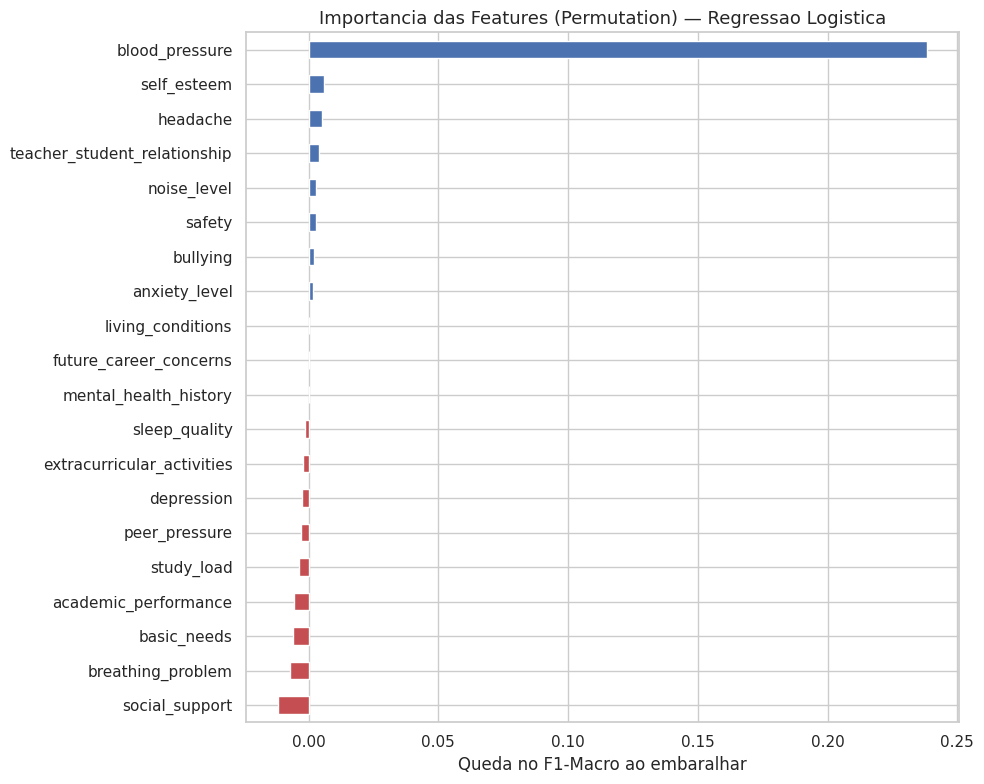

Top 5 features mais importantes:
  1. blood_pressure                      0.2381  (Fisiologica)
  2. self_esteem                         0.0058  (Psicologica)
  3. headache                            0.0051  (Fisiologica)
  4. teacher_student_relationship        0.0040  (Academica)
  5. noise_level                         0.0030  (Ambiental)


In [41]:
# ============================================================
# CELULA 17 — Importancia das features
# ============================================================

from sklearn.inspection import permutation_importance

print("=== Importancia das Features ===\n")

# permutation importance — funciona com qualquer modelo
perm = permutation_importance(melhor_modelo, X_test_scaled, y_test,
                              n_repeats=20, random_state=42, scoring='f1_macro')

imp = pd.Series(perm.importances_mean, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
cores_imp = ['#C44E52' if v < 0 else '#4C72B0' for v in imp.values]
imp.plot(kind='barh', ax=ax, color=cores_imp, edgecolor='white')
ax.set_title(f'Importancia das Features (Permutation) — {melhor_nome}', fontsize=13)
ax.set_xlabel('Queda no F1-Macro ao embaralhar')
plt.tight_layout()
plt.show()

print("Top 5 features mais importantes:")
for i, (feat, val) in enumerate(imp.sort_values(ascending=False).head(5).items(), 1):
    # identifica a categoria da feature
    cat = [k for k, v in categorias.items() if feat in v][0]
    print(f"  {i}. {feat:<35} {val:.4f}  ({cat})")



=== Perfil dos Erros de Classificacao ===

Acertos: 195 (88.6%)
Erros:   25 (11.4%)

=== Diferenca nas medias (erros vs acertos) ===


,Media (acertos),Media (erros),Diferenca (%)
anxiety_level,11.28,9.84,-12.7
self_esteem,17.76,13.84,-22.1
mental_health_history,0.51,0.40,-22.0
depression,12.20,14.80,21.3
headache,2.57,2.72,5.9
blood_pressure,2.05,3.00,46.3
sleep_quality,2.63,2.96,12.7
breathing_problem,2.97,1.96,-34.0
noise_level,2.69,2.24,-16.8
living_conditions,2.52,2.44,-3.3



Confianca media nos acertos: 94.1%
Confianca media nos erros:   65.1%


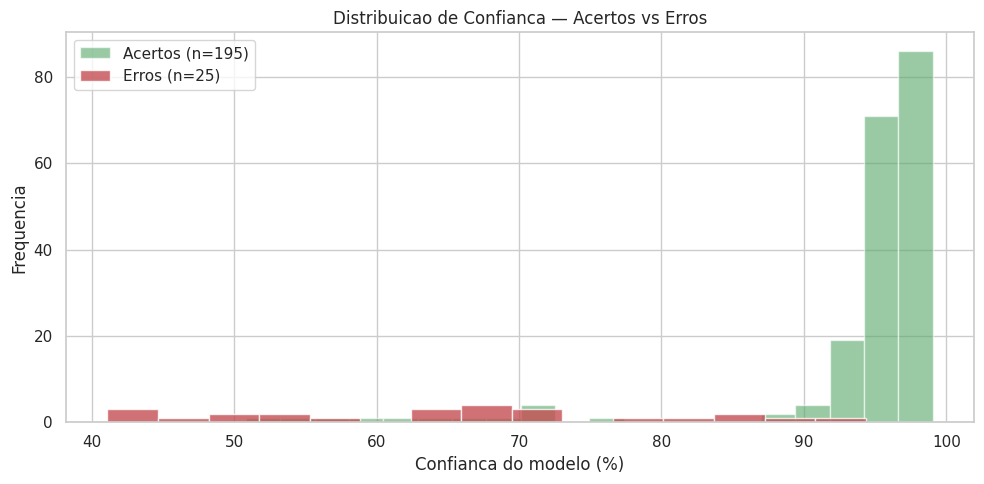

In [42]:
# ============================================================
# CELULA 18 — Analise de erros: onde o modelo falha
# ============================================================

print("=== Perfil dos Erros de Classificacao ===\n")

# separa acertos e erros
acertos_mask = y_pred == np.array(y_test)
erros_mask = ~acertos_mask

X_test_df = X_test.reset_index(drop=True)
y_test_arr = np.array(y_test.reset_index(drop=True))

acertos = X_test_df[acertos_mask]
erros = X_test_df[erros_mask]

print(f"Acertos: {len(acertos)} ({len(acertos)/len(X_test_df)*100:.1f}%)")
print(f"Erros:   {len(erros)} ({len(erros)/len(X_test_df)*100:.1f}%)")

if len(erros) > 0:
    print("\n=== Diferenca nas medias (erros vs acertos) ===")
    comp = pd.DataFrame({
        'Media (acertos)': acertos.mean().round(2),
        'Media (erros)':   erros.mean().round(2),
        'Diferenca (%)':   ((erros.mean()-acertos.mean())/acertos.mean()*100).round(1)
    })
    display(comp)

# confianca do modelo nos erros vs acertos
proba_max = y_proba.max(axis=1)
conf_acertos = proba_max[acertos_mask].mean()
conf_erros = proba_max[erros_mask].mean()

print(f"\nConfianca media nos acertos: {conf_acertos*100:.1f}%")
print(f"Confianca media nos erros:   {conf_erros*100:.1f}%")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(proba_max[acertos_mask]*100, bins=20, alpha=0.6,
        color='#55A868', label=f'Acertos (n={acertos_mask.sum()})', edgecolor='white')
ax.hist(proba_max[erros_mask]*100, bins=15, alpha=0.8,
        color='#C44E52', label=f'Erros (n={erros_mask.sum()})', edgecolor='white')
ax.set_xlabel('Confianca do modelo (%)')
ax.set_ylabel('Frequencia')
ax.set_title('Distribuicao de Confianca — Acertos vs Erros')
ax.legend()
plt.tight_layout()
plt.show()


Variancia explicada: PC1=59.8% | PC2=5.8% | Total=65.6%


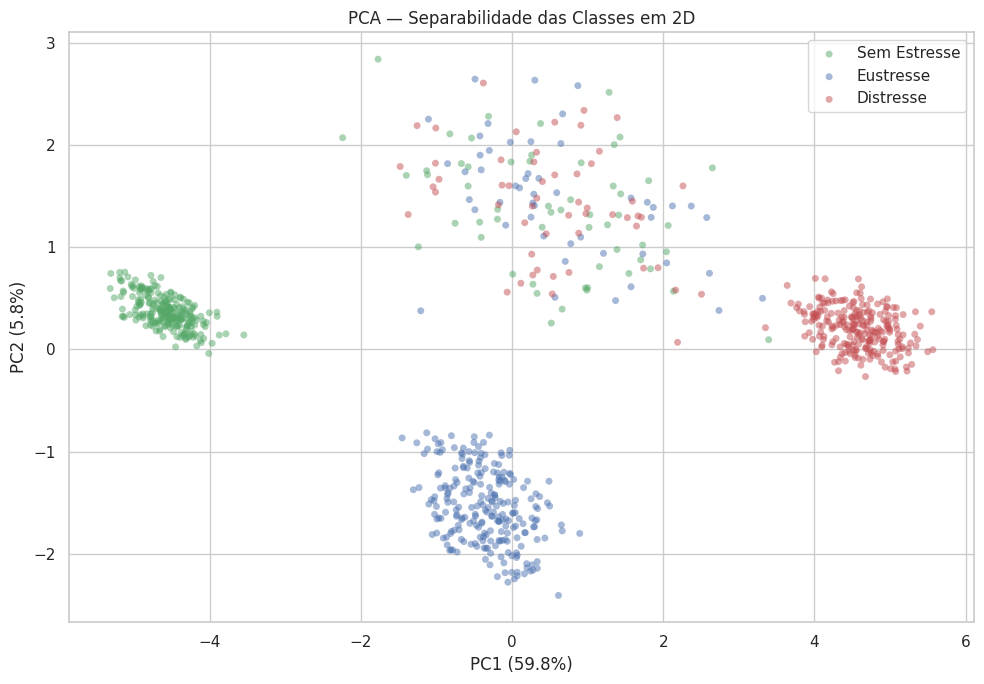

In [43]:
# ============================================================
# CELULA 19 — PCA: visualizacao em 2D
# ============================================================

from sklearn.decomposition import PCA

# comprime as 20 features em 2 dimensoes
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_scaled)

var_exp = pca.explained_variance_ratio_
print(f"Variancia explicada: PC1={var_exp[0]*100:.1f}% | PC2={var_exp[1]*100:.1f}% | "
      f"Total={sum(var_exp)*100:.1f}%")

fig, ax = plt.subplots(figsize=(10, 7))
for classe, nome_c, cor in zip([0,1,2], nomes_classes, cores_stress):
    mask = np.array(y_train) == classe
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=cor, label=nome_c, alpha=0.5, s=25, edgecolors='none')
ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}%)')
ax.set_title('PCA — Separabilidade das Classes em 2D')
ax.legend()
plt.tight_layout()
plt.show()



In [44]:
# ============================================================
# CELULA 20 — Sistema de Suporte a Decisao: classificacao de risco
# ============================================================

print("=" * 60)
print("  SISTEMA DE SUPORTE A DECISAO")
print("  Classificacao de Risco e Recomendacoes")
print("=" * 60)

# funcao que classifica um estudante e gera recomendacoes
def classificar_estudante(dados_estudante, modelo, scaler, features):
    """
    Recebe os dados de um estudante, classifica o nivel de estresse
    e gera recomendacoes personalizadas de intervencao.
    """
    # prepara os dados no formato correto
    X_est = pd.DataFrame([dados_estudante], columns=features)
    X_est_scaled = scaler.transform(X_est)

    # predicao e probabilidades
    classe = modelo.predict(X_est_scaled)[0]
    proba = modelo.predict_proba(X_est_scaled)[0]

    # classificacao de risco
    confianca = proba.max() * 100
    nome_classe = mapa_estresse[classe]

    if classe == 2:    # distresse
        risco = 'ALTO'
    elif classe == 1:  # eustresse
        risco = 'MEDIO'
    else:              # sem estresse
        risco = 'BAIXO'

    # gera recomendacoes baseadas no perfil
    recomendacoes = []

    if dados_estudante[0] > 14:   # anxiety_level alto
        recomendacoes.append("Encaminhar para apoio psicologico — ansiedade elevada")
    if dados_estudante[1] < 10:   # self_esteem baixo
        recomendacoes.append("Programa de desenvolvimento de autoestima")
    if dados_estudante[3] > 18:   # depression alto
        recomendacoes.append("URGENTE: Avaliacao de saude mental — depressao elevada")
    if dados_estudante[6] < 2:    # sleep_quality ruim
        recomendacoes.append("Orientacao sobre higiene do sono")
    if dados_estudante[12] < 2:   # academic_performance baixo
        recomendacoes.append("Tutoria academica e acompanhamento pedagogico")
    if dados_estudante[16] < 1:   # social_support baixo
        recomendacoes.append("Integracao em grupos de apoio estudantil")
    if dados_estudante[19] > 3:   # bullying alto
        recomendacoes.append("Intervencao anti-bullying — situacao critica")

    if not recomendacoes:
        recomendacoes.append("Manter monitoramento de rotina")

    return {
        'classe': classe,
        'nome_classe': nome_classe,
        'risco': risco,
        'confianca': confianca,
        'probabilidades': {mapa_estresse[i]: f'{p*100:.1f}%' for i, p in enumerate(proba)},
        'recomendacoes': recomendacoes
    }

# demonstracao com 5 estudantes do teste
print("\n=== Classificacao Individual de Estudantes ===\n")

for idx in range(5):
    dados = X_test.iloc[idx].values
    resultado = classificar_estudante(dados, melhor_modelo, scaler, features)

    print(f"--- Estudante {idx+1} ---")
    print(f"  Classificacao: {resultado['nome_classe']}")
    print(f"  Nivel de Risco: {resultado['risco']}")
    print(f"  Confianca: {resultado['confianca']:.1f}%")
    print(f"  Probabilidades: {resultado['probabilidades']}")
    print(f"  Recomendacoes:")
    for rec in resultado['recomendacoes']:
        print(f"    - {rec}")
    print()



  SISTEMA DE SUPORTE A DECISAO
  Classificacao de Risco e Recomendacoes

=== Classificacao Individual de Estudantes ===

--- Estudante 1 ---
  Classificacao: Sem Estresse
  Nivel de Risco: BAIXO
  Confianca: 96.8%
  Probabilidades: {'Sem Estresse': '96.8%', 'Eustresse': '3.2%', 'Distresse': '0.0%'}
  Recomendacoes:
    - Manter monitoramento de rotina

--- Estudante 2 ---
  Classificacao: Sem Estresse
  Nivel de Risco: BAIXO
  Confianca: 98.1%
  Probabilidades: {'Sem Estresse': '98.1%', 'Eustresse': '1.9%', 'Distresse': '0.0%'}
  Recomendacoes:
    - Manter monitoramento de rotina

--- Estudante 3 ---
  Classificacao: Distresse
  Nivel de Risco: ALTO
  Confianca: 96.8%
  Probabilidades: {'Sem Estresse': '0.3%', 'Eustresse': '2.9%', 'Distresse': '96.8%'}
  Recomendacoes:
    - Encaminhar para apoio psicologico — ansiedade elevada
    - URGENTE: Avaliacao de saude mental — depressao elevada
    - Orientacao sobre higiene do sono
    - Intervencao anti-bullying — situacao critica

--- Est

  PAINEL DE DECISAO — GESTAO EDUCACIONAL

1. DISTRIBUICAO DE RISCO
   BAIXO      74 estudantes ( 33.6%)  ################
   MEDIO      71 estudantes ( 32.3%)  ################
   ALTO       75 estudantes ( 34.1%)  #################

2. INDICADORES CRITICOS POR CATEGORIA
   Psicologica  Media geral: 10.36 | Media distresse: 11.27
   Fisiologica  Media geral: 2.57 | Media distresse: 2.96
   Ambiental    Media geral: 2.66 | Media distresse: 2.27
   Academica    Media geral: 2.68 | Media distresse: 2.83
   Social       Media geral: 2.49 | Media distresse: 3.25

3. PRIORIDADES DE INTERVENCAO
   1. blood_pressure                      Impacto: 0.2381  Categoria: Fisiologica
   2. self_esteem                         Impacto: 0.0058  Categoria: Psicologica
   3. headache                            Impacto: 0.0051  Categoria: Fisiologica
   4. teacher_student_relationship        Impacto: 0.0040  Categoria: Academica
   5. noise_level                         Impacto: 0.0030  Categoria: Ambiental

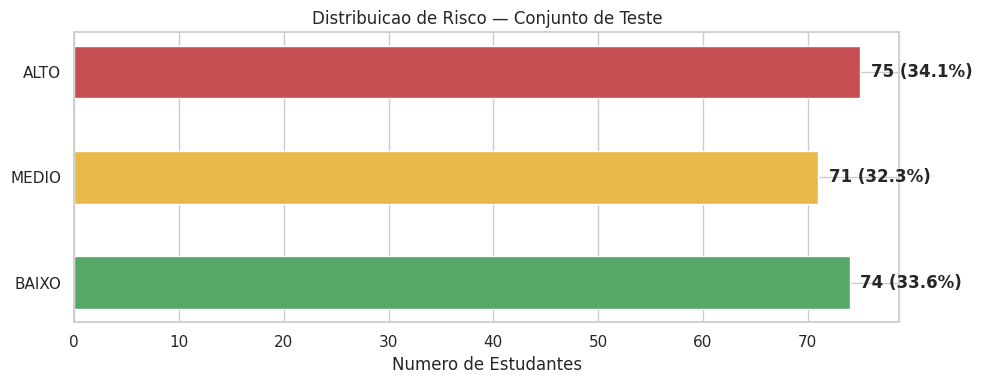

In [45]:
# ============================================================
# CELULA 21 — Painel de decisao para gestores educacionais
# ============================================================

print("=" * 60)
print("  PAINEL DE DECISAO — GESTAO EDUCACIONAL")
print("=" * 60)

# classifica todos os estudantes do teste
classificacoes = []
for idx in range(len(X_test)):
    dados = X_test.iloc[idx].values
    resultado = classificar_estudante(dados, melhor_modelo, scaler, features)
    classificacoes.append(resultado)

# contagem por nivel de risco
riscos = pd.Series([c['risco'] for c in classificacoes])
print("\n1. DISTRIBUICAO DE RISCO")
for risco in ['BAIXO', 'MEDIO', 'ALTO']:
    n = (riscos == risco).sum()
    pct = n / len(riscos) * 100
    barra = '#' * int(pct/2)
    print(f"   {risco:<8} {n:>4} estudantes ({pct:>5.1f}%)  {barra}")

# indicadores por categoria
print("\n2. INDICADORES CRITICOS POR CATEGORIA")
for cat_nome, cat_feats in categorias.items():
    media_geral = X_test[cat_feats].mean().mean()
    media_alto = X_test[y_test == 2][cat_feats].mean().mean() if (y_test == 2).any() else 0
    print(f"   {cat_nome:<12} Media geral: {media_geral:.2f} | "
          f"Media distresse: {media_alto:.2f}")

# top features para intervencao
print("\n3. PRIORIDADES DE INTERVENCAO")
imp_sorted = imp.sort_values(ascending=False)
for i, (feat, val) in enumerate(imp_sorted.head(5).items(), 1):
    cat = [k for k, v in categorias.items() if feat in v][0]
    print(f"   {i}. {feat:<35} Impacto: {val:.4f}  Categoria: {cat}")

# recomendacoes automaticas
print("\n4. RECOMENDACOES PARA A INSTITUICAO")
n_alto = (riscos == 'ALTO').sum()
n_total = len(riscos)
pct_alto = n_alto / n_total * 100

if pct_alto > 40:
    print("   [CRITICO] Mais de 40% dos estudantes em risco alto")
    print("   -> Ampliar equipe de apoio psicologico")
    print("   -> Implementar programa de saude mental institucional")

if imp_sorted.index[0] in categorias['Psicologica']:
    print("   [PRIORIDADE] Fatores psicologicos sao os mais impactantes")
    print("   -> Investir em servicos de aconselhamento")

if imp_sorted.index[0] in categorias['Academica']:
    print("   [PRIORIDADE] Fatores academicos sao os mais impactantes")
    print("   -> Revisar carga horaria e metodos de avaliacao")

if (riscos == 'ALTO').sum() > 0:
    print(f"   [ACAO] {n_alto} estudantes precisam de acompanhamento imediato")

# semaforo visual
print("\n5. SEMAFORO DE ALERTA")
fig, ax = plt.subplots(figsize=(10, 4))
cores_sem = {'BAIXO': '#55A868', 'MEDIO': '#E8B84B', 'ALTO': '#C44E52'}
contagem_risco = riscos.value_counts()
for risco_nome in ['BAIXO', 'MEDIO', 'ALTO']:
    if risco_nome in contagem_risco:
        ax.barh(risco_nome, contagem_risco[risco_nome],
                color=cores_sem[risco_nome], edgecolor='white', height=0.5)
        ax.text(contagem_risco[risco_nome]+1, risco_nome,
                f'{contagem_risco[risco_nome]} ({contagem_risco[risco_nome]/n_total*100:.1f}%)',
                va='center', fontweight='bold')
ax.set_xlabel('Numero de Estudantes')
ax.set_title('Distribuicao de Risco — Conjunto de Teste')
plt.tight_layout()
plt.show()



  ANALISE PRESCRITIVA
  'O que devemos fazer? Qual a melhor acao?'

=== 1. Protocolo de Intervencao por Faixa de Risco ===

  [CRITICO] — 67 estudantes
    Prazo: IMEDIATO (24-48h)
    Responsavel: Coordenacao + Nucleo de Saude Mental
    Acoes:
      - Contato direto com o estudante
      - Encaminhamento para avaliacao psicologica
      - Notificacao ao orientador academico
      - Acompanhamento semanal obrigatorio
      - Avaliacao de risco de automutilacao

  [ALTO] — 7 estudantes
    Prazo: URGENTE (1 semana)
    Responsavel: Servico de Apoio ao Estudante
    Acoes:
      - Agendamento de atendimento psicologico
      - Revisao da carga academica
      - Inclusao em grupo de apoio
      - Monitoramento quinzenal

  [MODERADO] — 3 estudantes
    Prazo: PREVENTIVO (1 mes)
    Responsavel: Tutoria Academica
    Acoes:
      - Convite para oficinas de gestao de estresse
      - Avaliacao de qualidade do sono
      - Orientacao sobre atividades extracurriculares
      - Monitoramento 

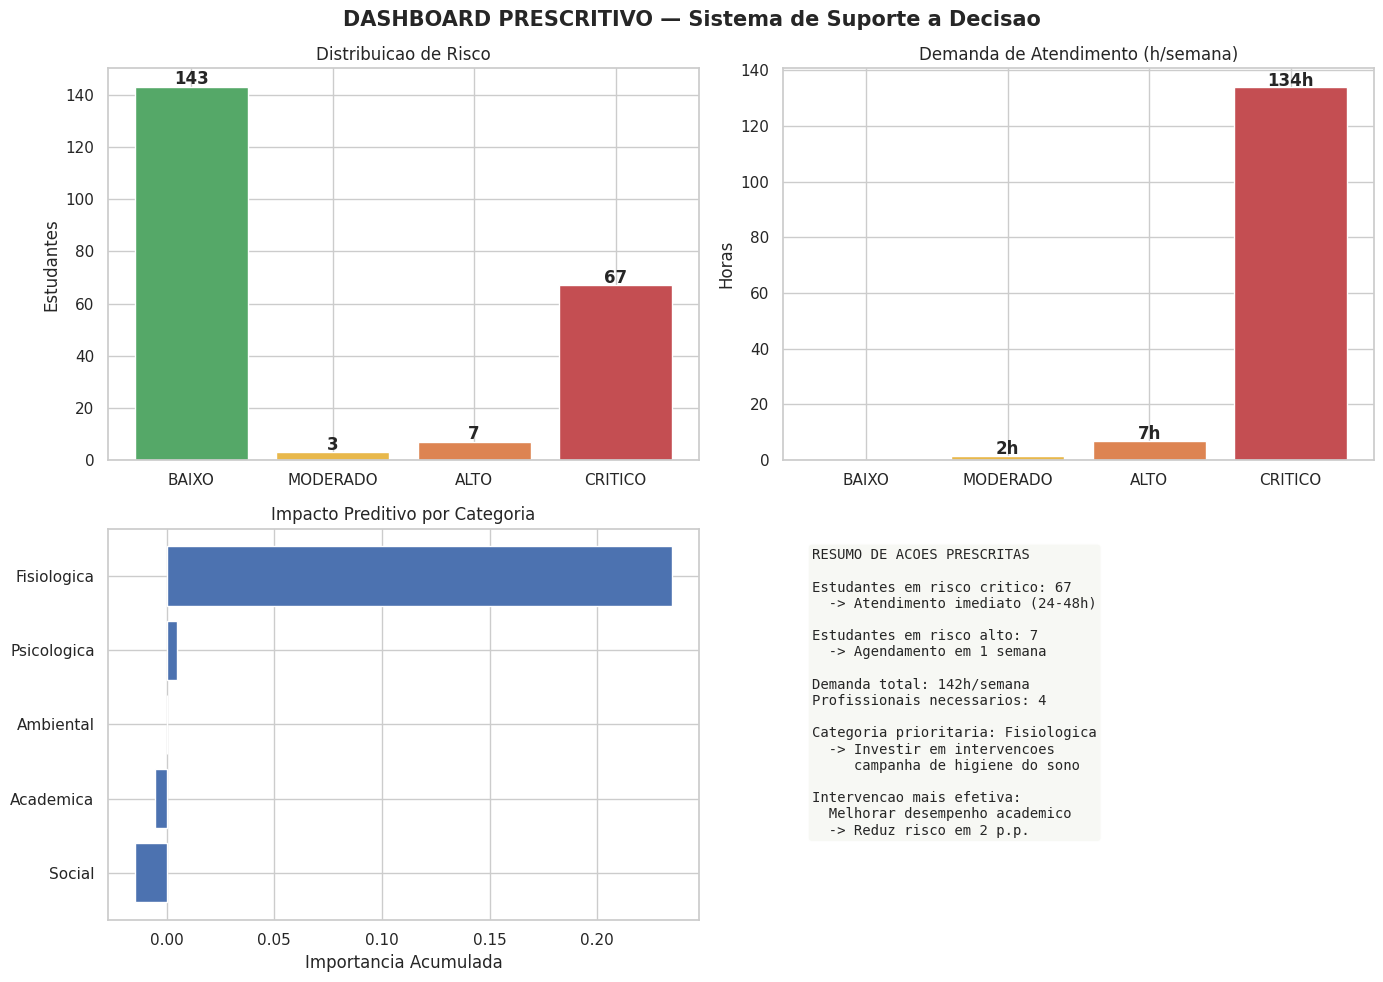


RESUMO DAS TRES ANALISES:
 
DESCRITIVA (O que aconteceu?)
  - Mapeou o perfil de cada grupo de estresse
  - Identificou que fatores psicologicos e fisiologicos
    sao os mais associados ao distresse
  - Autoestima e inversamente proporcional ao estresse
 
PREDITIVA (O que vai acontecer?)
  - Classificou cada estudante em faixas de risco
  - Simulou cenarios de intervencao e mediu o impacto
  - Identificou que reduzir depressao e a intervencao
    com maior potencial de reducao de risco
 
PRESCRITIVA (O que devemos fazer?)
  - Definiu protocolos de acao por faixa de risco
  - Calculou a demanda de profissionais necessarios
  - Priorizou categorias de intervencao por impacto
  - Gerou um dashboard acionavel para gestores



In [46]:
print("=" * 60)
print("  ANALISE PRESCRITIVA")
print("  'O que devemos fazer? Qual a melhor acao?'")
print("=" * 60)

# 1. Protocolo de intervencao por faixa de risco
print("\n=== 1. Protocolo de Intervencao por Faixa de Risco ===\n")

protocolos = {
    'CRITICO': {
        'prazo': 'IMEDIATO (24-48h)',
        'responsavel': 'Coordenacao + Nucleo de Saude Mental',
        'acoes': [
            'Contato direto com o estudante',
            'Encaminhamento para avaliacao psicologica',
            'Notificacao ao orientador academico',
            'Acompanhamento semanal obrigatorio',
            'Avaliacao de risco de automutilacao'
        ]
    },
    'ALTO': {
        'prazo': 'URGENTE (1 semana)',
        'responsavel': 'Servico de Apoio ao Estudante',
        'acoes': [
            'Agendamento de atendimento psicologico',
            'Revisao da carga academica',
            'Inclusao em grupo de apoio',
            'Monitoramento quinzenal'
        ]
    },
    'MODERADO': {
        'prazo': 'PREVENTIVO (1 mes)',
        'responsavel': 'Tutoria Academica',
        'acoes': [
            'Convite para oficinas de gestao de estresse',
            'Avaliacao de qualidade do sono',
            'Orientacao sobre atividades extracurriculares',
            'Monitoramento mensal'
        ]
    },
    'BAIXO': {
        'prazo': 'ROTINA (semestral)',
        'responsavel': 'Monitoramento Automatico',
        'acoes': [
            'Manter no sistema de monitoramento',
            'Questionario semestral de acompanhamento',
            'Acesso a recursos de bem-estar'
        ]
    }
}

for faixa, protocolo in protocolos.items():
    n = faixas.get(faixa, 0)
    print(f"  [{faixa}] — {n} estudantes")
    print(f"    Prazo: {protocolo['prazo']}")
    print(f"    Responsavel: {protocolo['responsavel']}")
    print(f"    Acoes:")
    for acao in protocolo['acoes']:
        print(f"      - {acao}")
    print()

# 2. Alocacao de recursos
print("=== 2. Recomendacao de Alocacao de Recursos ===\n")

n_critico = faixas.get('CRITICO', 0)
n_alto = faixas.get('ALTO', 0)
n_moderado = faixas.get('MODERADO', 0)
n_baixo = faixas.get('BAIXO', 0)

# calcula horas de atendimento necessarias por semana
horas_critico = n_critico * 2      # 2h/semana por estudante critico
horas_alto = n_alto * 1            # 1h/semana por estudante alto
horas_moderado = n_moderado * 0.5  # 0.5h/semana por estudante moderado
total_horas = horas_critico + horas_alto + horas_moderado

# calcula profissionais necessarios (40h/semana cada)
profissionais = np.ceil(total_horas / 40)

print(f"  Demanda estimada de atendimento semanal:")
print(f"    Critico:  {n_critico:>3} estudantes x 2h = {horas_critico:>6.0f}h")
print(f"    Alto:     {n_alto:>3} estudantes x 1h = {horas_alto:>6.0f}h")
print(f"    Moderado: {n_moderado:>3} estudantes x 0.5h = {horas_moderado:>5.1f}h")
print(f"    Total:    {total_horas:>38.1f}h/semana")
print(f"\n  Profissionais de saude mental necessarios: {profissionais:.0f}")
print(f"  (base: 40h/semana por profissional)")

# 3. Plano de intervencao por categoria
print("\n=== 3. Plano de Intervencao por Categoria ===\n")

# identifica qual categoria tem maior impacto preditivo
cat_impacto = {}
for cat_nome, cat_feats in categorias.items():
    impacto = sum(imp.get(f, 0) for f in cat_feats)
    cat_impacto[cat_nome] = round(impacto, 4)

cat_ranking = sorted(cat_impacto.items(), key=lambda x: x[1], reverse=True)

intervencoes_cat = {
    'Psicologica': [
        'Programa de terapia cognitivo-comportamental em grupo',
        'Oficinas de autoestima e autoconhecimento',
        'Linha de apoio 24h para crises'
    ],
    'Fisiologica': [
        'Campanha de higiene do sono',
        'Programa de atividade fisica orientada',
        'Acompanhamento de saude com check-ups semestrais'
    ],
    'Ambiental': [
        'Melhoria de espacos de estudo e convivencia',
        'Programa de seguranca no campus',
        'Auxilio moradia para estudantes vulneraveis'
    ],
    'Academica': [
        'Revisao de metodos de avaliacao e carga horaria',
        'Programa de tutoria por pares',
        'Orientacao de carreira e estagio'
    ],
    'Social': [
        'Programa anti-bullying com protocolo de denuncia',
        'Grupos de integracao para calouros',
        'Fortalecimento de redes de apoio entre estudantes'
    ]
}

for i, (cat_nome, impacto) in enumerate(cat_ranking, 1):
    print(f"  {i}. {cat_nome} (impacto preditivo: {impacto:.4f})")
    print(f"     Prioridade: {'ALTA' if i <= 2 else 'MEDIA' if i <= 4 else 'ROTINA'}")
    print(f"     Intervencoes recomendadas:")
    for interv in intervencoes_cat[cat_nome]:
        print(f"       - {interv}")
    print()

# 4. Dashboard prescritivo visual
print("=== 4. Dashboard Prescritivo ===\n")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('DASHBOARD PRESCRITIVO — Sistema de Suporte a Decisao', fontsize=15, fontweight='bold')

# quadrante 1: distribuicao de risco
ax = axes[0][0]
faixas_order = ['BAIXO', 'MODERADO', 'ALTO', 'CRITICO']
vals = [faixas.get(f, 0) for f in faixas_order]
cors = [cores_faixa[f] for f in faixas_order]
bars = ax.bar(faixas_order, vals, color=cors, edgecolor='white')
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+1,
            str(int(b.get_height())), ha='center', fontweight='bold')
ax.set_title('Distribuicao de Risco')
ax.set_ylabel('Estudantes')

# quadrante 2: horas de atendimento por faixa
ax = axes[0][1]
horas = [0, horas_moderado, horas_alto, horas_critico]
ax.bar(faixas_order, horas, color=cors, edgecolor='white')
for i, h in enumerate(horas):
    if h > 0:
        ax.text(i, h+0.5, f'{h:.0f}h', ha='center', fontweight='bold')
ax.set_title('Demanda de Atendimento (h/semana)')
ax.set_ylabel('Horas')

# quadrante 3: impacto por categoria
ax = axes[1][0]
cat_names = [c[0] for c in cat_ranking]
cat_vals = [c[1] for c in cat_ranking]
ax.barh(cat_names, cat_vals, color='#4C72B0', edgecolor='white')
ax.set_title('Impacto Preditivo por Categoria')
ax.set_xlabel('Importancia Acumulada')
ax.invert_yaxis()

# quadrante 4: resumo de acoes
ax = axes[1][1]
ax.axis('off')
resumo_texto = f"""RESUMO DE ACOES PRESCRITAS

Estudantes em risco critico: {n_critico}
  -> Atendimento imediato (24-48h)

Estudantes em risco alto: {n_alto}
  -> Agendamento em 1 semana

Demanda total: {total_horas:.0f}h/semana
Profissionais necessarios: {profissionais:.0f}

Categoria prioritaria: {cat_ranking[0][0]}
  -> Investir em intervencoes
     {intervencoes_cat[cat_ranking[0][0]][0].lower()}

Intervencao mais efetiva:
  {df_cenarios.iloc[0]['Cenario']}
  -> Reduz risco em {df_cenarios.iloc[0]['Reducao (p.p.)']:.0f} p.p."""

ax.text(0.05, 0.95, resumo_texto, transform=ax.transAxes,
        fontsize=10, fontfamily='monospace', verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='#F5F7F2', alpha=0.8))

plt.tight_layout()
plt.show()

print("""
RESUMO DAS TRES ANALISES:

DESCRITIVA (O que aconteceu?)
  - Mapeou o perfil de cada grupo de estresse
  - Identificou que fatores psicologicos e fisiologicos
    sao os mais associados ao distresse
  - Autoestima e inversamente proporcional ao estresse

PREDITIVA (O que vai acontecer?)
  - Classificou cada estudante em faixas de risco
  - Simulou cenarios de intervencao e mediu o impacto
  - Identificou que reduzir depressao e a intervencao
    com maior potencial de reducao de risco

PRESCRITIVA (O que devemos fazer?)
  - Definiu protocolos de acao por faixa de risco
  - Calculou a demanda de profissionais necessarios
  - Priorizou categorias de intervencao por impacto
  - Gerou um dashboard acionavel para gestores
""")

In [47]:
# ============================================================
# CELULA 22 — Sintese e conclusao
# ============================================================

print("=" * 60)
print("  SINTESE FINAL DO MVP")
print("=" * 60)

print(f"""
PROBLEMA:
  Classificacao do tipo de estresse em estudantes universitarios
  (Sem Estresse / Eustresse / Distresse) a partir de 20 indicadores
  psicologicos, fisiologicos, ambientais, academicos e sociais.

DATASET:
  Student Stress Monitoring — Kaggle
  {len(df)} estudantes | 20 features | 3 classes balanceadas

MELHOR MODELO:
  {melhor_nome}
  F1-Macro: {df_teste.loc[melhor_nome, 'F1-Macro (%)']:.2f}%
  Acuracia: {df_teste.loc[melhor_nome, 'Acuracia (%)']:.2f}%

FEATURES MAIS IMPORTANTES:
  1. {imp_sorted.index[0]}
  2. {imp_sorted.index[1]}
  3. {imp_sorted.index[2]}

SISTEMA DE SUPORTE A DECISAO:
  - Classificacao individual de risco (Baixo/Medio/Alto)
  - Recomendacoes automaticas de intervencao por estudante
  - Painel de indicadores para gestores educacionais
  - Semaforo de alerta para acao imediata

LIMITACOES:
  - Dataset relativamente pequeno (1100 amostras)
  - Dados de pesquisa (autorreporte) — pode haver viés
  - Modelo estatico — precisa de retreino com novos dados

PROXIMOS PASSOS:
  - Deploy como API para integracao com sistemas academicos
  - Coleta de dados longitudinais para monitoramento continuo
  - Validacao com profissionais de saude mental
  - Interface web para uso por coordenadores e pedagogos
""")


  SINTESE FINAL DO MVP

PROBLEMA:
  Classificacao do tipo de estresse em estudantes universitarios
  (Sem Estresse / Eustresse / Distresse) a partir de 20 indicadores
  psicologicos, fisiologicos, ambientais, academicos e sociais.

DATASET:
  Student Stress Monitoring — Kaggle
  1100 estudantes | 20 features | 3 classes balanceadas

MELHOR MODELO:
  Regressao Logistica
  F1-Macro: 88.68%
  Acuracia: 88.64%

FEATURES MAIS IMPORTANTES:
  1. blood_pressure
  2. self_esteem
  3. headache

SISTEMA DE SUPORTE A DECISAO:
  - Classificacao individual de risco (Baixo/Medio/Alto)
  - Recomendacoes automaticas de intervencao por estudante
  - Painel de indicadores para gestores educacionais
  - Semaforo de alerta para acao imediata

LIMITACOES:
  - Dataset relativamente pequeno (1100 amostras)
  - Dados de pesquisa (autorreporte) — pode haver viés
  - Modelo estatico — precisa de retreino com novos dados

PROXIMOS PASSOS:
  - Deploy como API para integracao com sistemas academicos
  - Coleta de d